In [9]:
import os

OUTPUT_DIR = "manuscript_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


#### Step 1: Dataset Preparation & Curation

In [12]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, PandasTools
from rdkit.Chem.MolStandardize import rdMolStandardize
import numpy as np

##### i)Load the dataset

In [15]:
df = pd.read_csv('panS_inhibitors.csv')

##### ii)Display initial info

In [18]:
print(f"Initial dataset size: {len(df)}")
print(df.head())

Initial dataset size: 149
   S.No Compound                                 SMILES  Activity
0     1       5a            C1(N2CCNCC2)=NOC3=CC=CC=C13  4.512129
1     2       5b          ClC1=C2C(ON=C2N3CCNCC3)=CC=C1  3.978071
2     3       5c          ClC1=CC=C2C(ON=C2N3CCNCC3)=C1  4.279101
3     4       5d          ClC1=C(ON=C2N3CCNCC3)C2=CC=C1  3.978071
4     5       6a  O=S(N1CCN(C2=NOC3=CC=CC=C23)CC1)(C)=O  4.352306


##### iii)Standardize molecules

In [21]:
def standardize_mol(smiles):
    """Standardize SMILES: neutralize, remove salts, canonicalize"""
        
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Remove salts (keep largest organic fragment)
        remover = rdMolStandardize.FragmentRemover()
        mol = remover.remove(mol)

        # Neutralize charges
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)

        # Canonicalize SMILES
        return Chem.MolToSmiles(mol, canonical=True)

    except Exception as e:
        return None

##### iv)Apply Standardization

In [24]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')
df['Standardized_SMILES'] = df['SMILES'].apply(standardize_mol)

##### v) Remove failed standardizations

In [27]:
df = df.dropna(subset=['Standardized_SMILES'])
print(f"After standardization: {len(df)} molecules")

After standardization: 149 molecules


##### vi) Add RDKit mol objects

In [30]:
PandasTools.AddMoleculeColumnToFrame(df, 'Standardized_SMILES', 'Molecule')

##### vii) Calculate basic descriptors

In [33]:
df['MW'] = df['Molecule'].apply(lambda x: Descriptors.MolWt(x))
df['LogP'] = df['Molecule'].apply(lambda x: Descriptors.MolLogP(x))
df['HBA'] = df['Molecule'].apply(lambda x: Descriptors.NumHAcceptors(x))
df['HBD'] = df['Molecule'].apply(lambda x: Descriptors.NumHDonors(x))
df['TPSA'] = df['Molecule'].apply(lambda x: Descriptors.TPSA(x))
df['RotBonds'] = df['Molecule'].apply(lambda x: Descriptors.NumRotatableBonds(x))
print("✓ Descriptors calculated: MW, LogP, HBA, HBD, TPSA, RotBonds")

✓ Descriptors calculated: MW, LogP, HBA, HBD, TPSA, RotBonds


##### viii) Save cleaned dataset

In [36]:
df.to_csv('panc_inhibitors_clean.csv', index=False)
print("\n✓ Dataset cleaned and saved!")
print(df[['Standardized_SMILES', 'MW', 'LogP', 'HBA', 'HBD']].head())


✓ Dataset cleaned and saved!
                 Standardized_SMILES       MW    LogP  HBA  HBD
0            c1ccc2c(N3CCNCC3)noc2c1  203.245  1.2374    4    1
1          Clc1cccc2onc(N3CCNCC3)c12  237.690  1.8908    4    1
2          Clc1ccc2c(N3CCNCC3)noc2c1  237.690  1.8908    4    1
3          Clc1cccc2c(N3CCNCC3)noc12  237.690  1.8908    4    1
4  CS(=O)(=O)N1CCN(c2noc3ccccc23)CC1  281.337  0.9094    5    0


##### TABLE 1 — Physicochemical Summary

In [39]:
summary_stats = df[['MW','LogP','HBA','HBD','TPSA','RotBonds']].describe().T
summary_stats = summary_stats[['mean','std','min','max']]
summary_stats.reset_index(inplace=True)
summary_stats.rename(columns={'index':'Property'}, inplace=True)

save_table(summary_stats, "Table1_Physicochemical_Summary.csv")
summary_stats


Saved: manuscript_outputs\Table1_Physicochemical_Summary.csv


,Property,mean,std,min,max
0,MW,387.591584,61.484483,203.24500,555.7860
1,LogP,3.831983,1.074914,0.47682,6.6028
2,HBA,5.228188,1.405207,3.00000,9.0000
3,HBD,0.684564,0.605016,0.00000,3.0000
4,TPSA,68.945235,17.001515,32.51000,133.4800
5,RotBonds,4.355705,1.390478,1.00000,10.0000


#### Step 2: Cheminformatics Analysis

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, Scaffolds
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

##### i) Load cleaned dataset

In [103]:
df = pd.read_csv('panc_inhibitors_clean.csv')
df['Molecule'] = df['Standardized_SMILES'].apply(Chem.MolFromSmiles)

##### 1. Physicochemical Property Distribution

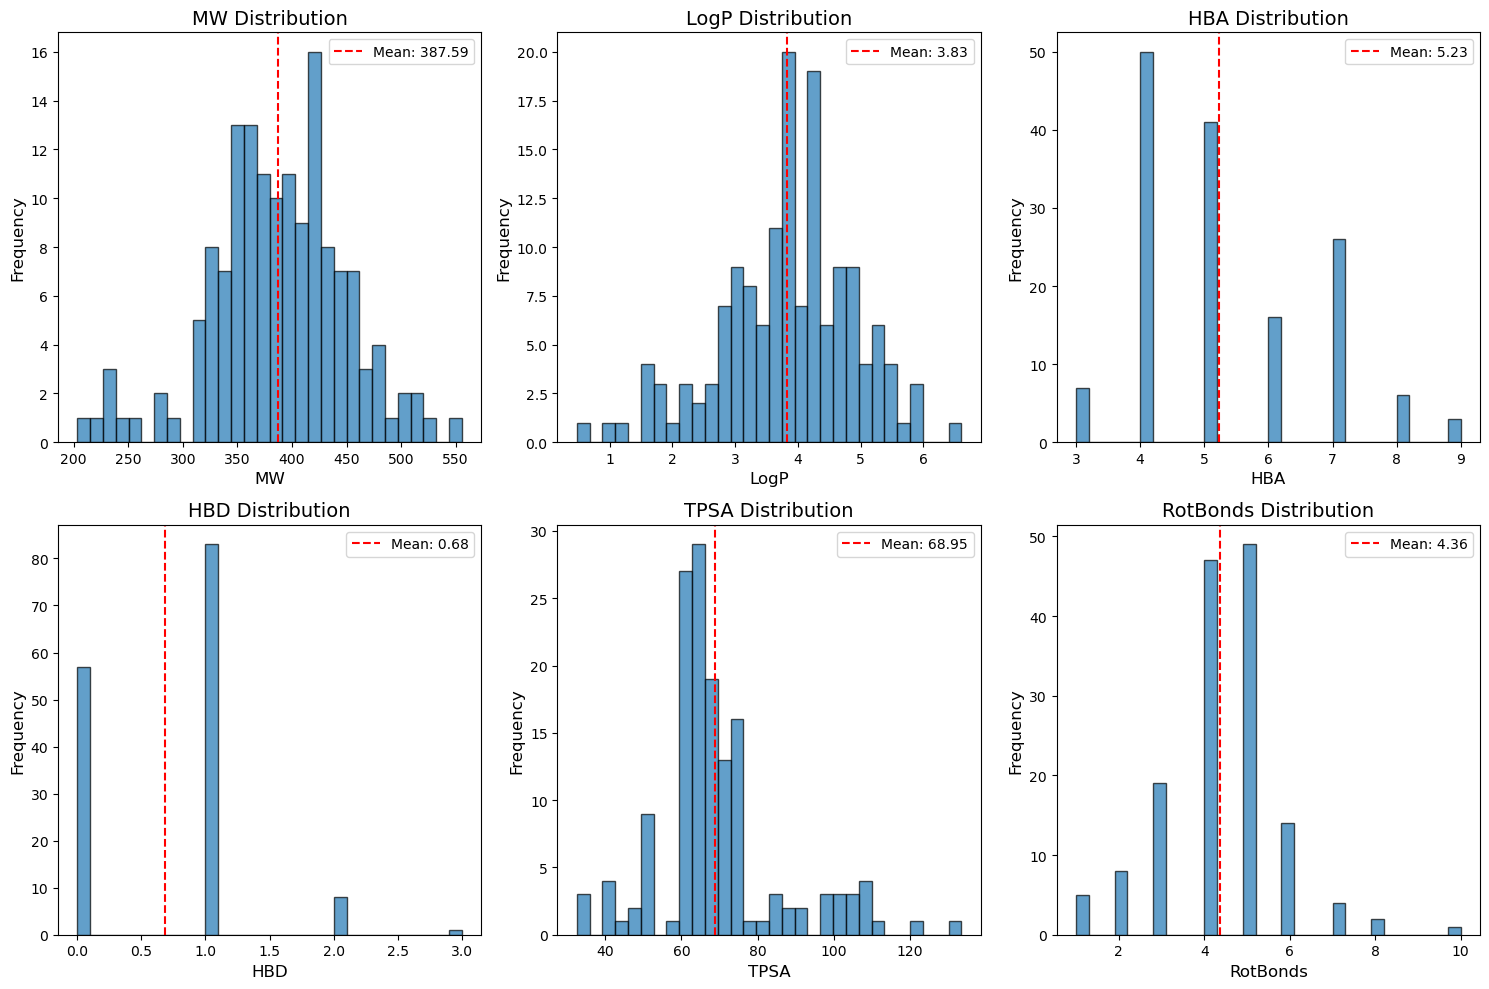

In [106]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
properties = ['MW', 'LogP', 'HBA', 'HBD', 'TPSA', 'RotBonds']

for idx, prop in enumerate(properties):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[prop], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(prop, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{prop} Distribution', fontsize=14)
    ax.axvline(df[prop].mean(), color='red', linestyle='--', label=f'Mean: {df[prop].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.savefig('property_distributions.png', dpi=300)
plt.show()

##### 2. Scaffold Analysis

In [108]:
def get_murcko_scaffold(mol):
    """Extract Murcko scaffold"""
    try:
        return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    except:
        return None

df['Scaffold'] = df['Molecule'].apply(get_murcko_scaffold)
scaffold_counts = df['Scaffold'].value_counts()

print(f"\n=== Scaffold Analysis ===")
print(f"Total unique scaffolds: {len(scaffold_counts)}")
print(f"\nTop 10 most common scaffolds:")
print(scaffold_counts.head(10))


=== Scaffold Analysis ===
Total unique scaffolds: 42

Top 10 most common scaffolds:
Scaffold
O=C(COc1ccnc2ccccc12)Nc1ccccc1                   39
O=S(=O)(c1ccccc1)N1CCN(c2noc3ccccc23)CC1         20
c1ccc(-n2cc(CN3CCN(c4noc5ccccc45)CC3)nn2)cc1     16
c1ccc2c(N3CCNCC3)noc2c1                          10
c1ccc(-n2cc(CN3CCCN(c4noc5ccccc45)CC3)nn2)cc1    10
O=C(Nc1cnn(Cc2ccccc2)c1)c1noc2c1CCCC2             8
O=C(Nc1cnn(Cc2ccccc2)c1)C1=NOC2CCCCC12            3
O=C(Cc1c[nH]c2ccccc12)N1CCN(c2noc3ccccc23)CC1     2
O=C(COc1ccnc2ccccc12)Nc1ccncc1                    2
O=C(COc1ccnc2ccccc12)Nc1nccs1                     2
Name: count, dtype: int64


##### i) Visualize scaffold diversity

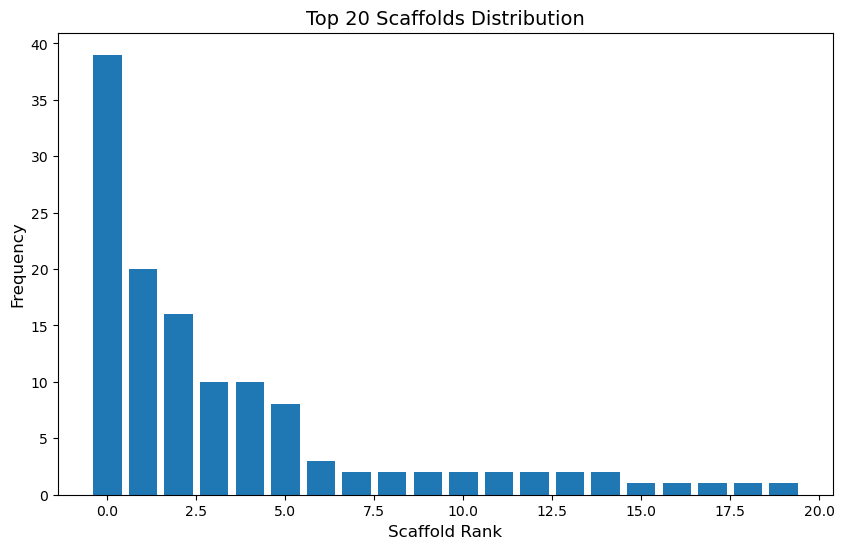

In [110]:
plt.figure(figsize=(10, 6))
plt.bar(range(min(20, len(scaffold_counts))), scaffold_counts.head(20).values)
plt.xlabel('Scaffold Rank', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Top 20 Scaffolds Distribution', fontsize=14)
plt.savefig('scaffold_distribution.png', dpi=300)
plt.show()

##### ii) Visualize the scaffolds

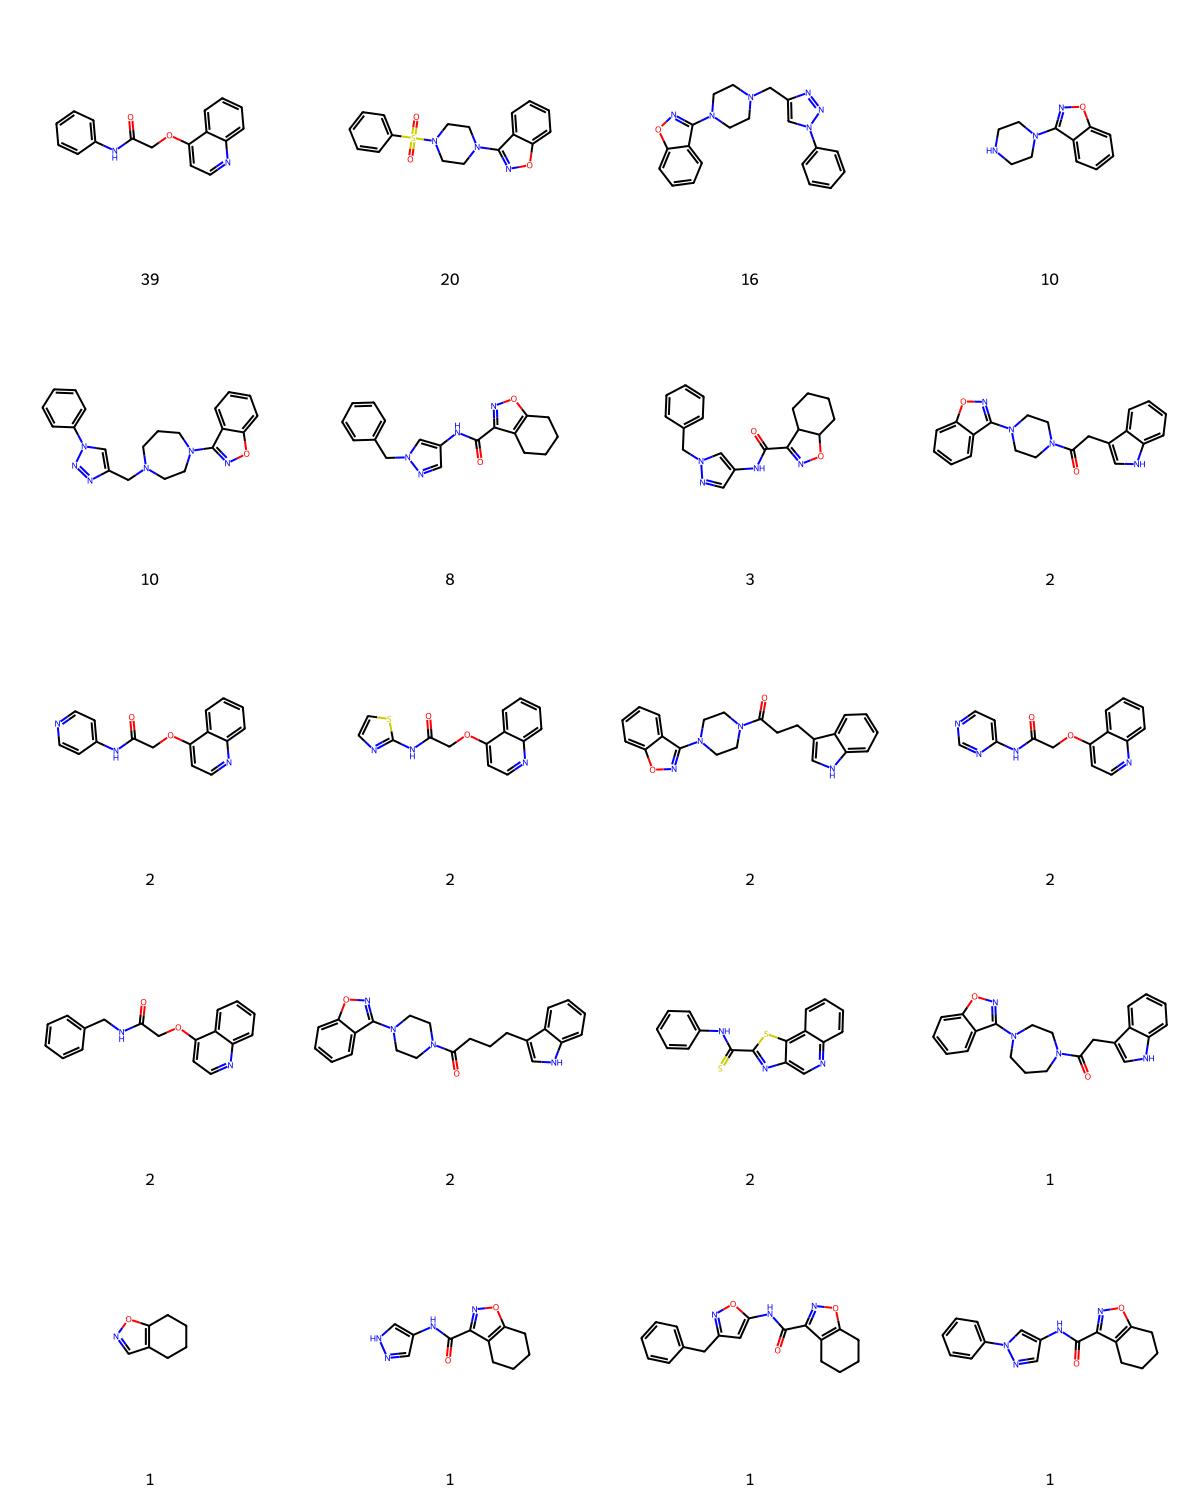

In [115]:
from rdkit import Chem
from rdkit.Chem import Draw

# Number of scaffolds to visualize
top_n = 20  

top_scaffolds = scaffold_counts.head(top_n)

# Convert to RDKit molecules
scaffold_mols = []
labels = []
for scaffold, count in top_scaffolds.items():
    mol = Chem.MolFromSmiles(scaffold)
    if mol:
        scaffold_mols.append(mol)
        labels.append(f"{count}")

# Draw grid: molecules + overlay counts
img = Draw.MolsToGridImage(
    scaffold_mols,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=labels,
    useSVG=False
)

img

##### iii) Save the Scaffolds as SDF

In [118]:
from rdkit import Chem
from rdkit.Chem import SDWriter

top_n = 50  # choose number of scaffolds to export (can change)

top_scaffolds = scaffold_counts.head(top_n)

writer = SDWriter("top_scaffolds.sdf")

for scaffold, count in top_scaffolds.items():
    mol = Chem.MolFromSmiles(scaffold)
    if mol:
        # Annotate metadata
        mol.SetProp("_Name", scaffold)
        mol.SetProp("Frequency", str(count))
        writer.write(mol)

writer.close()

print("Saved SDF file: top_scaffolds.sdf")

Saved SDF file: top_scaffolds.sdf


##### scaffold analysis figure and Table

=== Scaffold Analysis ===
Total unique scaffolds: 42

Top 10 most common scaffolds:
Scaffold
O=C(COc1ccnc2ccccc12)Nc1ccccc1                   39
O=S(=O)(c1ccccc1)N1CCN(c2noc3ccccc23)CC1         20
c1ccc(-n2cc(CN3CCN(c4noc5ccccc45)CC3)nn2)cc1     16
c1ccc2c(N3CCNCC3)noc2c1                          10
c1ccc(-n2cc(CN3CCCN(c4noc5ccccc45)CC3)nn2)cc1    10
O=C(Nc1cnn(Cc2ccccc2)c1)c1noc2c1CCCC2             8
O=C(Nc1cnn(Cc2ccccc2)c1)C1=NOC2CCCCC12            3
O=C(Cc1c[nH]c2ccccc12)N1CCN(c2noc3ccccc23)CC1     2
O=C(COc1ccnc2ccccc12)Nc1ccncc1                    2
O=C(COc1ccnc2ccccc12)Nc1nccs1                     2
Name: count, dtype: int64


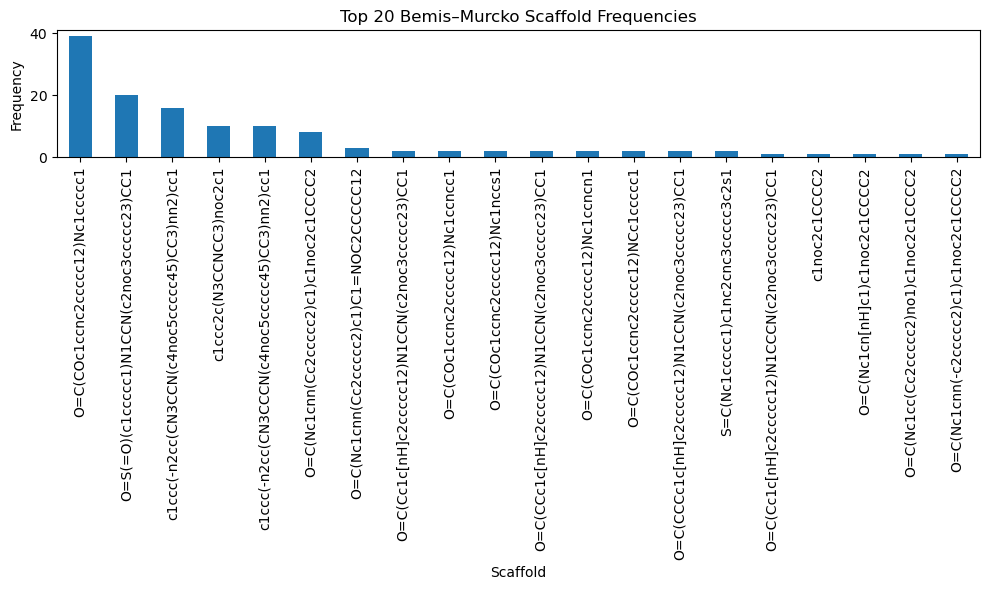

AttributeError: 'Image' object has no attribute 'save'

In [121]:
# ==============================
# Scaffold Analysis (Manuscript Ready - Single Cell)
# ==============================

from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
import matplotlib.pyplot as plt
import os

# Create output directory
OUTPUT_DIR = "manuscript_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------
# 1. Extract Bemis–Murcko Scaffolds
# ------------------------------
scaffolds = []

for mol in df['Molecule']:
    if mol is not None:
        try:
            scaffold = MurckoScaffold.GetScaffoldForMol(mol)
            scaffolds.append(Chem.MolToSmiles(scaffold))
        except:
            scaffolds.append(None)
    else:
        scaffolds.append(None)

df['Scaffold'] = scaffolds

# ------------------------------
# 2. Count Unique Scaffolds
# ------------------------------
scaffold_counts = df['Scaffold'].value_counts().dropna()

print("=== Scaffold Analysis ===")
print(f"Total unique scaffolds: {len(scaffold_counts)}")
print("\nTop 10 most common scaffolds:")
print(scaffold_counts.head(10))

# ------------------------------
# 3. Save Full Scaffold Frequency Table (Supplementary Table)
# ------------------------------
scaffold_table = scaffold_counts.reset_index()
scaffold_table.columns = ['Scaffold_SMILES', 'Frequency']
scaffold_table.to_csv(os.path.join(OUTPUT_DIR, 
                     "Supplementary_Table_Scaffold_Frequencies.csv"), 
                     index=False)

# ------------------------------
# 4. Plot Top 20 Scaffold Frequencies (Figure S1A)
# ------------------------------
top_n = 20
top_scaffolds = scaffold_counts.head(top_n)

fig = plt.figure(figsize=(10,6))
top_scaffolds.plot(kind='bar')
plt.ylabel("Frequency")
plt.title("Top 20 Bemis–Murcko Scaffold Frequencies")
plt.xticks(rotation=90)
plt.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, 
            "FigureS1A_Scaffold_Frequencies.png"), dpi=600)
fig.savefig(os.path.join(OUTPUT_DIR, 
            "FigureS1A_Scaffold_Frequencies.pdf"))

plt.show()

# ------------------------------
# 5. Save Top 20 Scaffold Structures Grid (Figure S1B)
# ------------------------------
scaffold_mols = [Chem.MolFromSmiles(s) for s in top_scaffolds.index]

img = Draw.MolsToGridImage(
    scaffold_mols,
    molsPerRow=5,
    subImgSize=(400,400)
)

img.save(os.path.join(OUTPUT_DIR, 
         "FigureS1B_Top20_Scaffolds.png"))

print("\nAll scaffold outputs saved in 'manuscript_outputs' folder.")


##### 3. Chemical Space Visualization (PCA)

##### i) Generate Morgan fingerprints

In [124]:
def generate_fingerprint(mol, radius=2, nBits=2048):
    try:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
    except:
        return None

fps = [generate_fingerprint(m) for m in df['Molecule']]
fp_array = np.array([list(fp) for fp in fps if fp is not None])

##### ii) PCA

In [127]:
scaler = StandardScaler()
fp_scaled = scaler.fit_transform(fp_array)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(fp_scaled)

##### iii) Plot

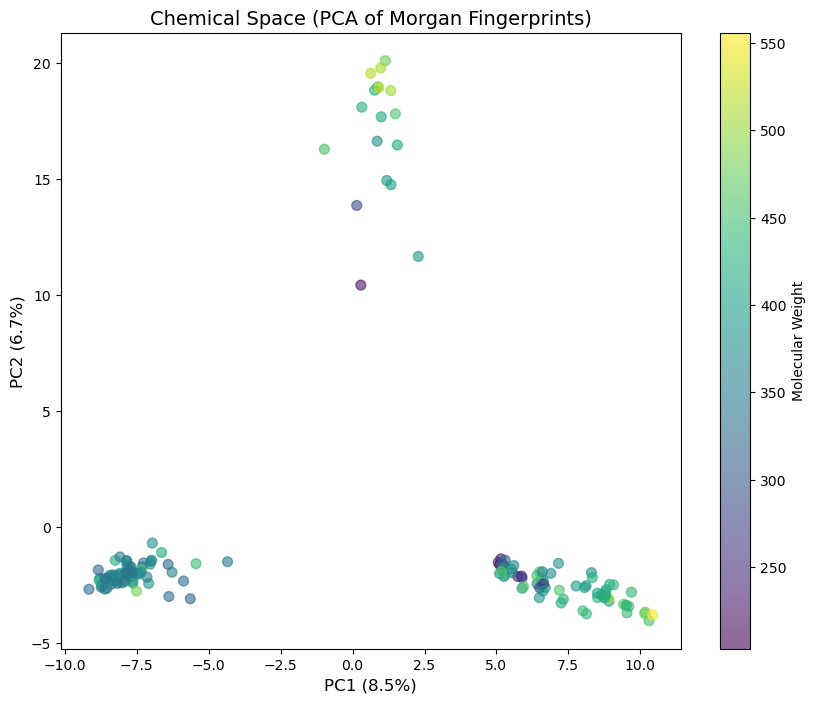


✓ Cheminformatics analysis complete!
Explained variance: PC1=0.085, PC2=0.067


In [130]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], 
                     c=df['MW'][:len(pca_result)], cmap='viridis', 
                     alpha=0.6, s=50)
plt.colorbar(scatter, label='Molecular Weight')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Chemical Space (PCA of Morgan Fingerprints)', fontsize=14)
plt.savefig('chemical_space_pca.png', dpi=300)
plt.show()

print(f"\n✓ Cheminformatics analysis complete!")
print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")

##### 4. Enhanced Diversity Analysis for Highly Diverse Datasets

In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# UMAP import (assuming already installed)
import umap

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform


ModuleNotFoundError: No module named 'umap'

##### i) Load data

In [ ]:
df = pd.read_csv('panS_inhibitors_clean.csv')
df['Molecule'] = df['Standardized_SMILES'].apply(Chem.MolFromSmiles)

##### ii) Generate fingerprints

In [136]:
fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in df['Molecule']]
fp_array = np.array([list(fp) for fp in fps])

print("="*70)
print("ENHANCED DIVERSITY ANALYSIS")
print("="*70)

ENHANCED DIVERSITY ANALYSIS


###### A. Cumulative Explained Variance

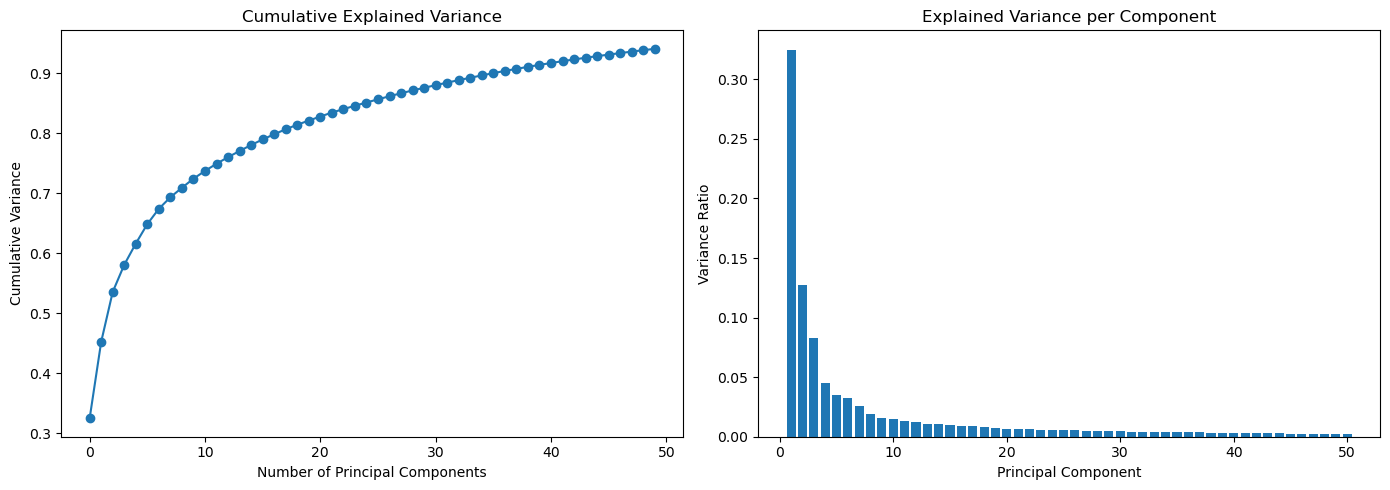

In [139]:
# Compute PCA on fingerprints
pca = PCA(n_components=50)
pca_result = pca.fit_transform(fp_array)

# Cumulative variance
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: cumulative explained variance ---
ax1.plot(cumvar, marker='o')
ax1.set_title("Cumulative Explained Variance")
ax1.set_xlabel("Number of Principal Components")
ax1.set_ylabel("Cumulative Variance")

# --- Right: individual explained variance ---
ax2.bar(range(1, len(pca.explained_variance_ratio_)+1),
        pca.explained_variance_ratio_)
ax2.set_title("Explained Variance per Component")
ax2.set_xlabel("Principal Component")
ax2.set_ylabel("Variance Ratio")

plt.tight_layout()
plt.show()


###### B. Individual variance

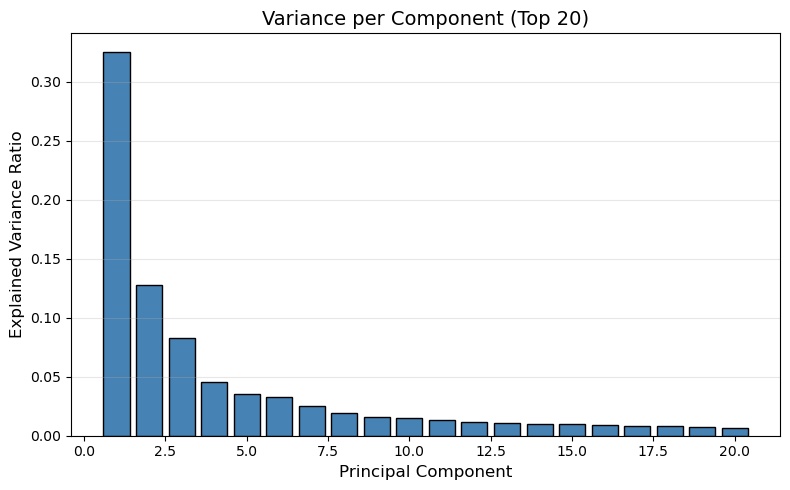

In [142]:
# Fit PCA
pca = PCA(n_components=50)
pca_result = pca.fit_transform(fp_array)

# Plot top-20 individual PC variances
fig, ax1 = plt.subplots(figsize=(8,5))

num_components = min(20, len(pca.explained_variance_ratio_))

ax1.bar(
    range(1, num_components + 1),
    pca.explained_variance_ratio_[:num_components],
    color='steelblue',
    edgecolor='black'
)

ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Explained Variance Ratio', fontsize=12)
ax1.set_title('Variance per Component (Top 20)', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

###### C. Cumulative variance

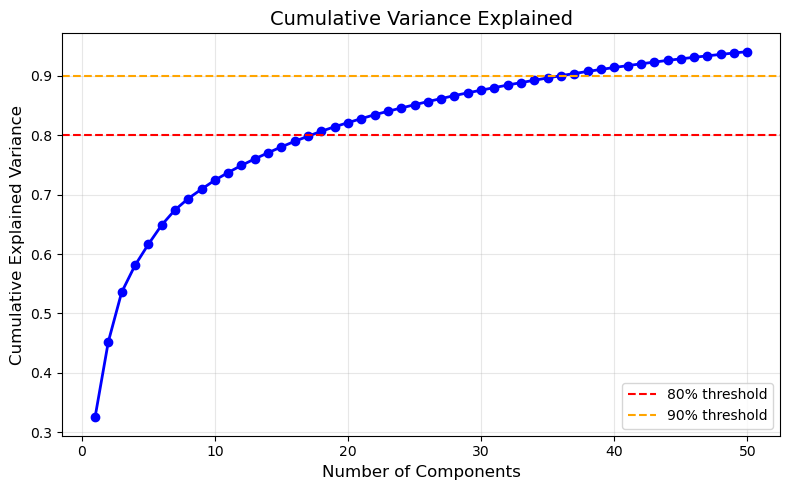


=== PCA Variance Analysis Summary ===
PC1 + PC2 contribution: 45.24%
PC1 contribution alone: 32.49%
Top-5 PCs: 61.63%
Top-10 PCs: 72.45%
80% variance requires: 18 components
90% variance requires: 36 components
→ Indicates moderate dimensionality reduction possible.
→ High chemical diversity confirmed.


In [145]:
# --- PCA cumulative variance analysis ---

pca = PCA(n_components=50)
pca_result = pca.fit_transform(fp_array)

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax2 = plt.subplots(figsize=(8,5))

ax2.plot(range(1, len(cumvar)+1), cumvar, 'bo-', linewidth=2)

# Thresholds
ax2.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
ax2.axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')

ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Explained Variance', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=300)
plt.show()

# Components required to reach thresholds
n_components_80 = np.argmax(cumvar >= 0.8) + 1 if np.any(cumvar >= 0.8) else None
n_components_90 = np.argmax(cumvar >= 0.9) + 1 if np.any(cumvar >= 0.9) else None

print("\n=== PCA Variance Analysis Summary ===")
print(f"PC1 + PC2 contribution: {cumvar[1]:.2%}")
print(f"PC1 contribution alone: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Top-5 PCs: {cumvar[4]:.2%}")
print(f"Top-10 PCs: {cumvar[9]:.2%}")
print(f"80% variance requires: {n_components_80} components")
print(f"90% variance requires: {n_components_90} components")

if n_components_80 and n_components_80 > 20:
    print("→ Indicates high intrinsic dimensionality.")
else:
    print("→ Indicates moderate dimensionality reduction possible.")

print("→ High chemical diversity confirmed.")

###### D. t-SNE VISUALIZATION (Better for Complex Datasets)

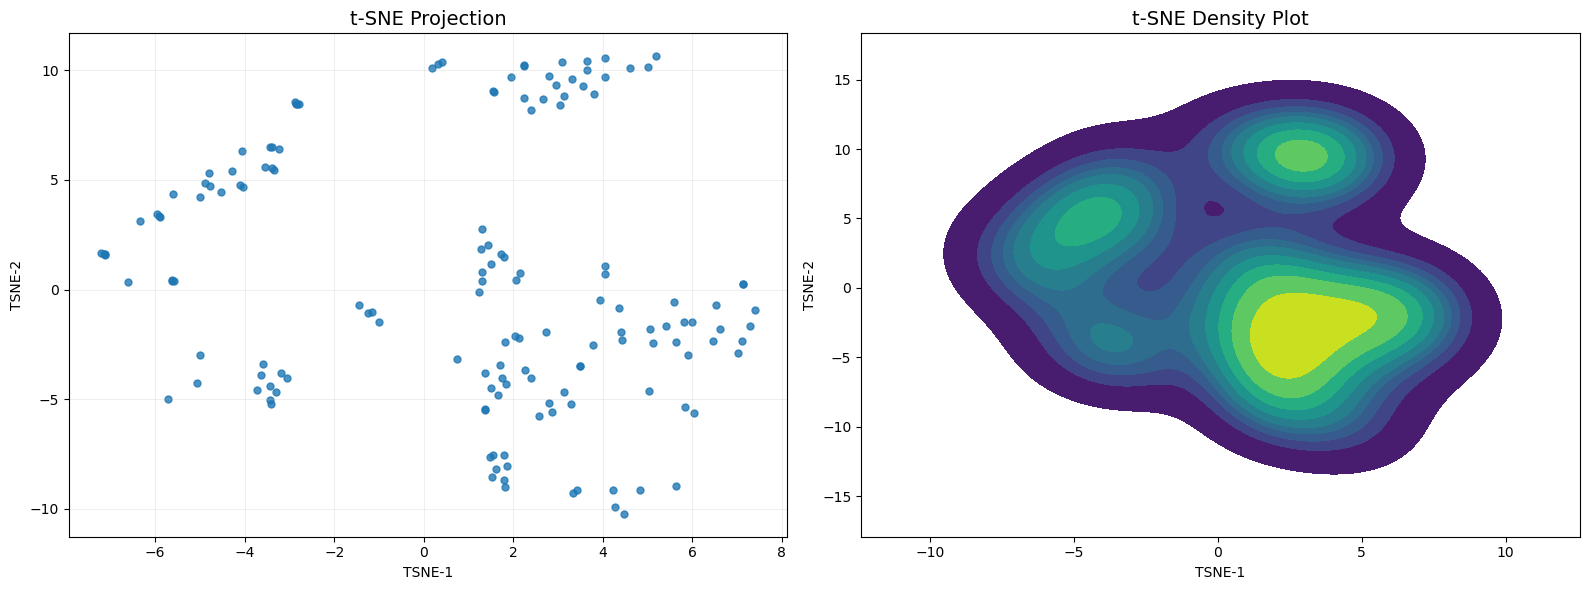

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# -----------------------------
# Prepare feature matrix
# -----------------------------
X = df.select_dtypes(include=[np.number])  # numeric descriptor columns only
X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -----------------------------
# Run t-SNE
# -----------------------------
tsne = TSNE(
    n_components=2,
    random_state=42,
    init='pca',
    learning_rate='auto'
)

tsne_result = tsne.fit_transform(X_scaled)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    s=25,
    alpha=0.8
)

axes[0].set_title("t-SNE Projection", fontsize=14)
axes[0].set_xlabel("TSNE-1")
axes[0].set_ylabel("TSNE-2")
axes[0].grid(alpha=0.2)

# Density
sns.kdeplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    fill=True,
    cmap="viridis",
    ax=axes[1]
)

axes[1].set_title("t-SNE Density Plot", fontsize=14)
axes[1].set_xlabel("TSNE-1")
axes[1].set_ylabel("TSNE-2")

plt.tight_layout()
plt.show()

###### E. Color by activity

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# Run t-SNE
print("\nRunning t-SNE (better for nonlinear chemical spaces)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1200,
    metric="euclidean",
    random_state=42
)

tsne_result = tsne.fit_transform(fp_array)

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

activity_col = 'Activity'   # numeric pMIC

# --- Scatter colored by pMIC ---
scatter1 = axes[0].scatter(
    tsne_result[:, 0],
    tsne_result[:, 1],
    c=df[activity_col],
    cmap='viridis',
    alpha=0.85,
    s=55,
    edgecolors='k',
    linewidth=0.3
)

cbar = fig.colorbar(scatter1, ax=axes[0])
cbar.set_label('pMIC (Potency)', fontsize=12)

axes[0].set_title('t-SNE Colored by Activity (pMIC)', fontsize=14)
axes[0].set_xlabel('t-SNE-1')
axes[0].set_ylabel('t-SNE-2')
axes[0].grid(alpha=0.3)

# --- KDE density map on second subplot ---
sns.kdeplot(
    x=tsne_result[:, 0],
    y=tsne_result[:, 1],
    fill=True,
    cmap='viridis',
    alpha=0.75,
    ax=axes[1]
)

axes[1].set_title('t-SNE Density Map', fontsize=14)
axes[1].set_xlabel('t-SNE-1')
axes[1].set_ylabel('t-SNE-2')

plt.tight_layout()
plt.show()



Running t-SNE (better for nonlinear chemical spaces)...


TypeError: TSNE.__init__() got an unexpected keyword argument 'max_iter'

###### F. Cluster t-SNE using HDBSCAN

In [ ]:
!pip install hdbscan
import hdbscan

clusterer = hdbscan.HDBSCAN(min_cluster_size=5)
cluster_labels = clusterer.fit_predict(tsne_result)

df['Cluster'] = cluster_labels
print(np.unique(cluster_labels))

###### G. Dominant Scaffold Per Cluster + 2D Visualization

In [153]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from PIL import Image
import io

# =====================================================
# 1) Generate Murcko Scaffold Column
# =====================================================

df['Scaffold'] = df['Molecule'].apply(
    lambda mol: MurckoScaffold.MurckoScaffoldSmiles(mol=mol) if mol else None
)

# Remove rows without scaffold (safety step)
df = df.dropna(subset=['Scaffold'])

print("\nScaffold column created successfully.")
print(df[['SMILES', 'Scaffold']].head())


# =====================================================
# 2) Find Dominant Scaffold per Cluster
# =====================================================

cluster_rep_scaf = (
    df.groupby('Cluster')['Scaffold']
      .agg(lambda x: x.value_counts().idxmax())
      .reset_index(name='Representative_Scaffold')
)

print("\nRepresentative scaffold per cluster:")
print(cluster_rep_scaf)


# =====================================================
# 3) Convert Scaffold SMILES → RDKit Mol
# =====================================================

cluster_rep_scaf['Mol'] = cluster_rep_scaf['Representative_Scaffold'].apply(
    Chem.MolFromSmiles
)

# Remove invalid molecules if any
cluster_rep_scaf = cluster_rep_scaf.dropna(subset=['Mol'])


# =====================================================
# 4) Draw Scaffold Grid (Publication-Friendly)
# =====================================================

mols = cluster_rep_scaf['Mol'].tolist()
labels = ['Cluster ' + str(c) for c in cluster_rep_scaf['Cluster']]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 300),
    legends=labels,
    useSVG=False
)

# Display in notebook
display(img)


# =====================================================
# 5) Save Scaffold Panel (Robust Save Block)
# =====================================================

save_name = "cluster_representative_scaffolds.png"

if hasattr(img, 'save'):
    img.save(save_name)

elif isinstance(img, np.ndarray):
    Image.fromarray(img).save(save_name)

elif hasattr(img, 'GetDrawingText'):
    png_bytes = img.GetDrawingText()
    pil_img = Image.open(io.BytesIO(png_bytes))
    pil_img.save(save_name)

elif isinstance(img, str) and img.strip().startswith("<svg"):
    save_name = "cluster_representative_scaffolds.svg"
    with open(save_name, "w", encoding="utf-8") as f:
        f.write(img)

print(f"\nSaved scaffold panel: {save_name}")


# =====================================================
# 6) Scaffold Frequency Table (Cluster-wise SAR Insight)
# =====================================================

cluster_scaf_freq = (
    df.groupby(['Cluster', 'Scaffold'])
      .size()
      .reset_index(name='Count')
      .sort_values(['Cluster', 'Count'], ascending=[True, False])
)

print("\nScaffold frequency per cluster:")
print(cluster_scaf_freq)



Scaffold column created successfully.
                                  SMILES                 Scaffold
0            C1(N2CCNCC2)=NOC3=CC=CC=C13  c1ccc2c(N3CCNCC3)noc2c1
1          ClC1=C2C(ON=C2N3CCNCC3)=CC=C1  c1ccc2c(N3CCNCC3)noc2c1
2          ClC1=CC=C2C(ON=C2N3CCNCC3)=C1  c1ccc2c(N3CCNCC3)noc2c1
3          ClC1=C(ON=C2N3CCNCC3)C2=CC=C1  c1ccc2c(N3CCNCC3)noc2c1
4  O=S(N1CCN(C2=NOC3=CC=CC=C23)CC1)(C)=O  c1ccc2c(N3CCNCC3)noc2c1


KeyError: 'Cluster'

In [ ]:
print(df.columns)

##### Extract the 5 Representatives per Cluster

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
import numpy as np
import pandas as pd

# ==========================================
# 1️⃣ Ensure Required Columns Exist
# ==========================================

required_cols = ['Molecule', 'Activity', 'Cluster']
for col in required_cols:
    if col not in df.columns:
        raise ValueError(f"Missing required column: {col}")

# ==========================================
# 2️⃣ Ensure Fingerprints Exist
# ==========================================

if 'FP' not in df.columns:
    df['FP'] = df['Molecule'].apply(
        lambda m: AllChem.GetMorganFingerprintAsBitVect(m, radius=2, nBits=2048)
        if m is not None else None
    )

# Convert fingerprints to numpy array
def fp_to_np(fp):
    arr = np.zeros((2048,), dtype=int)
    if fp is not None:
        DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

df['FP_arr'] = df['FP'].apply(fp_to_np)

# ==========================================
# 3️⃣ Ensure Scaffold Column Exists
# ==========================================

if 'Scaffold' not in df.columns:
    def get_murcko_scaffold(mol):
        try:
            return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
        except:
            return None

    df['Scaffold'] = df['Molecule'].apply(get_murcko_scaffold)

# ==========================================
# 4️⃣ Build Representatives per Cluster
# ==========================================

rep_list = []

for cluster, group in df.groupby('Cluster'):

    # Skip empty clusters
    if len(group) == 0:
        continue

    rep = {'Cluster': cluster}

    # ---------------------------
    # 1) Highest pMIC (SAR hotspot)
    # ---------------------------
    idx_max = group['Activity'].idxmax()
    rep['max_mol'] = group.loc[idx_max, 'Molecule']
    rep['max_pMIC'] = group.loc[idx_max, 'Activity']

    # ---------------------------
    # 2) Median pMIC (typical analog)
    # ---------------------------
    median_val = group['Activity'].median()
    median_idx = (group['Activity'] - median_val).abs().idxmin()
    rep['median_mol'] = group.loc[median_idx, 'Molecule']
    rep['median_pMIC'] = group.loc[median_idx, 'Activity']

    # ---------------------------
    # 3) Fingerprint Centroid (diversity representative)
    # ---------------------------
    fp_stack = np.vstack(group['FP_arr'])
    centroid = np.mean(fp_stack, axis=0)
    centroid_bits = (centroid > 0.5).astype(int)
    bitstring = ''.join(map(str, centroid_bits))
    cen_fp = DataStructs.CreateFromBitString(bitstring)

    sims = []
    for idx, row in group.iterrows():
        if row['FP'] is not None:
            sim = DataStructs.TanimotoSimilarity(row['FP'], cen_fp)
            sims.append((sim, idx))

    if sims:
        centroid_idx = max(sims, key=lambda x: x[0])[1]
        rep['centroid_mol'] = group.loc[centroid_idx, 'Molecule']
        rep['centroid_pMIC'] = group.loc[centroid_idx, 'Activity']
    else:
        rep['centroid_mol'] = None
        rep['centroid_pMIC'] = None

    # ---------------------------
    # 4) Random sampling
    # ---------------------------
    rand = group.sample(1).iloc[0]
    rep['random_mol'] = rand['Molecule']
    rep['random_pMIC'] = rand['Activity']

    # ---------------------------
    # 5) Potency-Weighted Scaffold Representative
    # ---------------------------
    if group['Scaffold'].notna().any():

        scaffold_stats = (
            group.groupby('Scaffold')['Activity']
            .agg(['mean', 'count'])
            .reset_index()
        )

        # Select scaffold with highest mean pMIC
        best_scaffold = scaffold_stats.sort_values(
            by='mean', ascending=False
        ).iloc[0]['Scaffold']

        rep['scaffold_smiles'] = best_scaffold
        rep['scaffold_mol'] = Chem.MolFromSmiles(best_scaffold)

        # Representative molecule of that scaffold
        scaffold_group = group[group['Scaffold'] == best_scaffold]
        idx_best = scaffold_group['Activity'].idxmax()
        rep['scaffold_rep_mol'] = scaffold_group.loc[idx_best, 'Molecule']
        rep['scaffold_rep_pMIC'] = scaffold_group.loc[idx_best, 'Activity']

    else:
        rep['scaffold_smiles'] = None
        rep['scaffold_mol'] = None
        rep['scaffold_rep_mol'] = None
        rep['scaffold_rep_pMIC'] = None

    rep_list.append(rep)

# ==========================================
# 5️⃣ Create Representative DataFrame
# ==========================================

rep_df = pd.DataFrame(rep_list)

print("Cluster Representatives Generated Successfully ✅")
rep_df.head()


#### Cluster Visual Panel + SAR

In [158]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Geometry import Point2D
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io

pmic_col = "Activity"
mol_col = "Molecule"

# =====================================================
# Ensure Scaffold + FP
# =====================================================
if "Scaffold" not in df.columns:
    df["Scaffold"] = df[mol_col].apply(
        lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None
    )

if "FP" not in df.columns:
    df["FP"] = df[mol_col].apply(
        lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) if m else None
    )

# =====================================================
# Centroid selection
# =====================================================
def get_centroid_row(sub):
    fps = sub["FP"].tolist()
    n = len(fps)
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if fps[i] and fps[j]:
                sim[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])
    idx = sim.mean(axis=1).argmax()
    return sub.iloc[idx]

# =====================================================
# pMIC color
# =====================================================
def pmic_to_color(p):
    if np.isnan(p):
        return (150, 150, 150)
    p = max(3, min(7, p))
    t = (p - 3) / 4
    return (int(255*(1-t)), int(255*t), 0)

# =====================================================
# Draw single molecule (independent canvas)
# =====================================================
def draw_molecule(mol, p):
    size = 320
    drawer = rdMolDraw2D.MolDraw2DCairo(size, size)
    opts = drawer.drawOptions()
    opts.clearBackground = True
    opts.setBackgroundColour((1,1,1))
    opts.addAtomIndices = False
    opts.padding = 0.2

    atoms = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() != 6]
    color_rgb = pmic_to_color(p)
    color_float = tuple(c/255 for c in color_rgb)
    atom_colors = {a: color_float for a in atoms}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=atoms,
        highlightAtomColors=atom_colors
    )

    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

# =====================================================
# Build cluster panels
# =====================================================
cluster_panels = []

for c in sorted(df.Cluster.unique()):

    sub = df[df.Cluster == c].copy()
    if len(sub) == 0:
        continue

    best = sub.loc[sub[pmic_col].idxmax()]
    median = sub.loc[(sub[pmic_col] - sub[pmic_col].median()).abs().idxmin()]
    centroid = get_centroid_row(sub)

    if sub["Scaffold"].notna().any():
        scaf_stats = sub.groupby("Scaffold")[pmic_col].mean()
        scaffold_smiles = scaf_stats.idxmax()
        scaffold = Chem.MolFromSmiles(scaffold_smiles)
    else:
        scaffold = None

    random = sub.sample(1).iloc[0]

    reps = [
        ("Best", best[mol_col], best[pmic_col], best["FP"]),
        ("Median", median[mol_col], median[pmic_col], median["FP"]),
        ("Centroid", centroid[mol_col], centroid[pmic_col], centroid["FP"]),
        ("Scaffold", scaffold, np.nan, None),
        ("Random", random[mol_col], random[pmic_col], random["FP"]),
    ]

    # Draw molecules individually
    mol_images = []
    for name, mol, p, fp in reps:
        if mol is None:
            mol_images.append(Image.new("RGB", (320,320), "white"))
            continue
        img = draw_molecule(mol, p)
        mol_images.append(img)

    # Create grid (3 x 2)
    grid = Image.new("RGB", (960, 700), "white")
    draw = ImageDraw.Draw(grid)

    for i, img in enumerate(mol_images):
        row = i // 3
        col = i % 3
        x = col * 320
        y = row * 320 + 80
        grid.paste(img, (x, y))

        name, mol, p, fp = reps[i]
        label = f"{name} | pMIC={p:.2f}" if not np.isnan(p) else name

        draw.text((x+10, y+270), label, fill="black")

        # Similarity
        if fp is not None and best["FP"] is not None:
            sim = DataStructs.TanimotoSimilarity(fp, best["FP"])
            draw.text((x+10, y+290), f"Sim={sim:.2f}", fill="black")

    # Header
    potency_range = sub[pmic_col].max() - sub[pmic_col].min()
    draw.text((20, 20), f"Cluster {c} | ΔpMIC={potency_range:.2f}", fill="black")

    # Legend bar
    legend_y = 640
    for i in range(300):
        t = i / 300
        color = (int(255*(1-t)), int(255*t), 0)
        draw.line([(330+i, legend_y), (330+i, legend_y+20)], fill=color)

    draw.text((330, legend_y+25), "Low (3)", fill="black")
    draw.text((600, legend_y+25), "High (7)", fill="black")

    cluster_panels.append(grid)

# =====================================================
# Stack all clusters vertically
# =====================================================
final_height = sum(p.height for p in cluster_panels) + 100*(len(cluster_panels)-1)
final = Image.new("RGB", (960, final_height), "white")

y = 0
for p in cluster_panels:
    final.paste(p, (0, y))
    y += p.height + 100

final.save("cluster_SAR_professional_layout.png", dpi=(600,600))

from IPython.display import display
display(final)


AttributeError: 'DataFrame' object has no attribute 'Cluster'

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io
import os

pmic_col = "Activity"
mol_col = "Molecule"

# =====================================================
# Ensure Scaffold + FP
# =====================================================
if "Scaffold" not in df.columns:
    df["Scaffold"] = df[mol_col].apply(
        lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None
    )

if "FP" not in df.columns:
    df["FP"] = df[mol_col].apply(
        lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) if m else None
    )

# =====================================================
# Centroid selection
# =====================================================
def get_centroid_row(sub):
    fps = sub["FP"].tolist()
    n = len(fps)
    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if fps[i] and fps[j]:
                sim[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])
    idx = sim.mean(axis=1).argmax()
    return sub.iloc[idx]

# =====================================================
# pMIC color
# =====================================================
def pmic_to_color(p):
    if np.isnan(p):
        return (150,150,150)
    p = max(3, min(7, p))
    t = (p - 3) / 4
    return (int(255*(1-t)), int(255*t), 0)

# =====================================================
# Draw molecule (large for PPT)
# =====================================================
def draw_molecule(mol, p):
    size = 400
    drawer = rdMolDraw2D.MolDraw2DCairo(size, size)
    opts = drawer.drawOptions()
    opts.clearBackground = True
    opts.setBackgroundColour((1,1,1))
    opts.padding = 0.2

    atoms = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() != 6]
    color = pmic_to_color(p)
    atom_colors = {a: tuple(c/255 for c in color) for a in atoms}

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=atoms,
        highlightAtomColors=atom_colors
    )

    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

# =====================================================
# Create PPT image per cluster
# =====================================================
output_dir = "ppt_cluster_images"
os.makedirs(output_dir, exist_ok=True)

for c in sorted(df.Cluster.unique()):

    sub = df[df.Cluster == c].copy()
    if len(sub) == 0:
        continue

    best = sub.loc[sub[pmic_col].idxmax()]
    median = sub.loc[(sub[pmic_col] - sub[pmic_col].median()).abs().idxmin()]
    centroid = get_centroid_row(sub)

    if sub["Scaffold"].notna().any():
        scaf_stats = sub.groupby("Scaffold")[pmic_col].mean()
        scaffold_smiles = scaf_stats.idxmax()
        scaffold = Chem.MolFromSmiles(scaffold_smiles)
    else:
        scaffold = None

    random = sub.sample(1).iloc[0]

    reps = [
        ("Best", best[mol_col], best[pmic_col], best["FP"]),
        ("Median", median[mol_col], median[pmic_col], median["FP"]),
        ("Centroid", centroid[mol_col], centroid[pmic_col], centroid["FP"]),
        ("Scaffold", scaffold, np.nan, None),
        ("Random", random[mol_col], random[pmic_col], random["FP"]),
    ]

    # 16:9 layout (PPT friendly)
    canvas = Image.new("RGB", (1920, 1080), "white")
    draw = ImageDraw.Draw(canvas)

    # Header
    potency_range = sub[pmic_col].max() - sub[pmic_col].min()
    draw.text((80, 40), f"Cluster {c}   |   ΔpMIC = {potency_range:.2f}",
              fill="black")

    # Grid positions
    positions = [
        (150,150), (700,150), (1250,150),
        (150,650), (700,650)
    ]

    for i, (name, mol, p, fp) in enumerate(reps):

        if mol is None:
            continue

        img = draw_molecule(mol, p)
        x, y = positions[i]
        canvas.paste(img, (x, y))

        label = f"{name} | pMIC={p:.2f}" if not np.isnan(p) else name
        draw.text((x, y+420), label, fill="black")

        # Similarity (skip Best)
        if name != "Best" and fp is not None:
            sim = DataStructs.TanimotoSimilarity(fp, best["FP"])
            draw.text((x, y+450), f"Sim={sim:.2f}", fill="black")

    # Legend bar
    legend_y = 1000
    for i in range(600):
        t = i / 600
        color = (int(255*(1-t)), int(255*t), 0)
        draw.line([(650+i, legend_y), (650+i, legend_y+30)], fill=color)

    draw.text((650, legend_y+40), "Low (pMIC 3)", fill="black")
    draw.text((1150, legend_y+40), "High (pMIC 7)", fill="black")

    filename = os.path.join(output_dir, f"Cluster_{c}_PPT.png")
    canvas.save(filename, dpi=(300,300))

print("PPT cluster images saved in:", output_dir)


In [161]:
"""
Clean Professional Cluster Visualization
=========================================
Guaranteed Saving • No Overlap • Stable
"""

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io
import os
from IPython.display import display

# =====================================================
# Configuration
# =====================================================

pmic_col = "Activity"
mol_col = "Molecule"

CANVAS_W = 3600
CANVAS_H = 3000
MOL_SIZE = 800

# =====================================================
# Prepare Data
# =====================================================

if "Scaffold" not in df.columns:
    df["Scaffold"] = df[mol_col].apply(
        lambda m: MurckoScaffold.MurckoScaffoldSmiles(mol=m) if m else None
    )

if "FP" not in df.columns:
    df["FP"] = df[mol_col].apply(
        lambda m: AllChem.GetMorganFingerprintAsBitVect(m, 2, 2048) if m else None
    )

# =====================================================
# Font Loader
# =====================================================

def load_font(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "C:\\Windows\\Fonts\\arial.ttf",
        "arial.ttf"
    ]:
        try:
            return ImageFont.truetype(path, size)
        except:
            continue
    return ImageFont.load_default()

fonts = {
    "title": load_font(110),
    "header": load_font(90),
    "text": load_font(70),
    "small": load_font(60)
}

# =====================================================
# Helper Functions
# =====================================================

def get_centroid(sub):
    fps = sub["FP"].tolist()
    n = len(fps)
    if n == 1:
        return sub.iloc[0]

    sim = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if fps[i] is not None and fps[j] is not None:
                sim[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

    return sub.iloc[sim.mean(axis=1).argmax()]


def color_from_pmic(p):
    if np.isnan(p):
        return (150, 150, 150)
    p = max(3, min(7, p))
    t = (p - 3) / 4
    return (int(255 * (1 - t)), int(255 * t), 0)


def draw_mol(mol, p):
    drawer = rdMolDraw2D.MolDraw2DCairo(MOL_SIZE, MOL_SIZE)
    opts = drawer.drawOptions()
    opts.clearBackground = True
    opts.padding = 0.08

    try:
        opts.bondLineWidth = 3
    except:
        pass

    atoms = [a.GetIdx() for a in mol.GetAtoms() if a.GetAtomicNum() != 6]
    color = color_from_pmic(p)

    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer,
        mol,
        highlightAtoms=atoms,
        highlightAtomColors={a: tuple(c/255 for c in color) for a in atoms}
    )

    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

# =====================================================
# Main Visualization
# =====================================================

def visualize_cluster(c):

    sub = df[df.Cluster == c].copy()
    if len(sub) == 0:
        print(f"No data for cluster {c}")
        return

    best = sub.loc[sub[pmic_col].idxmax()]
    median = sub.loc[(sub[pmic_col] - sub[pmic_col].median()).abs().idxmin()]
    centroid = get_centroid(sub)
    random = sub.sample(1).iloc[0]

    scaffold = None
    if sub["Scaffold"].notna().any():
        scaf_smiles = sub.groupby("Scaffold")[pmic_col].mean().idxmax()
        scaffold = Chem.MolFromSmiles(scaf_smiles)

    delta = sub[pmic_col].max() - sub[pmic_col].min()
    n = len(sub)

    canvas = Image.new("RGB", (CANVAS_W, CANVAS_H), "white")
    draw = ImageDraw.Draw(canvas)

    # Header
    header = f"Cluster {c}  |  ΔpMIC = {delta:.2f}  |  {n} compounds"
    bbox = draw.textbbox((0, 0), header, font=fonts["header"])
    w = bbox[2] - bbox[0]
    x = (CANVAS_W - w) // 2

    draw.rectangle([x - 40, 50, x + w + 40, 180],
                   fill=(240,248,255),
                   outline=(100,149,237),
                   width=4)
    draw.text((x, 75), header, fill="black", font=fonts["header"])

    positions = {
        "Best": (200, 280),
        "Median": (1700, 280),
        "Centroid": (200, 1430),
        "Random": (1700, 1430),
        "Scaffold": (1400, 2150)
    }

    reps = [
        ("Best", best[mol_col], best[pmic_col], best["FP"]),
        ("Median", median[mol_col], median[pmic_col], median["FP"]),
        ("Centroid", centroid[mol_col], centroid[pmic_col], centroid["FP"]),
        ("Random", random[mol_col], random[pmic_col], random["FP"]),
        ("Scaffold", scaffold, np.nan, None)
    ]

    for name, mol, p, fp in reps:
        if mol is None:
            continue

        x, y = positions[name]
        canvas.paste(draw_mol(mol, p), (x, y))

        if name == "Best":
            draw.rectangle([x-15, y-15, x+MOL_SIZE+15, y+MOL_SIZE+15],
                           outline=(0,100,255), width=18)

    # Legend (lowered to avoid overlap)
    lx, ly = 900, 2700
    legend_w = 1800
    legend_h = 100

    for i in range(legend_w):
        p_val = 3 + (i / legend_w) * 4
        draw.line([(lx+i, ly), (lx+i, ly+legend_h)],
                  fill=color_from_pmic(p_val))

    draw.rectangle([lx, ly, lx+legend_w, ly+legend_h],
                   outline="black", width=6)

    # =====================================================
    # SAVE (Absolute Path Guaranteed)
    # =====================================================

    output_dir = os.path.join(os.getcwd(), "Clusters")
    os.makedirs(output_dir, exist_ok=True)

    filepath = os.path.join(output_dir, f"Cluster_{c}.png")

    canvas.save(filepath, format="PNG", dpi=(300,300))

    print("Saved to:", filepath)

    display(canvas)
    return canvas


def visualize_all():
    clusters = sorted(df.Cluster.unique())
    print("Clusters detected:", clusters)
    for c in clusters:
        visualize_cluster(c)
    print("\nAll clusters saved.")

print("READY → Run visualize_cluster(4) or visualize_all()")


READY → Run visualize_cluster(4) or visualize_all()


In [163]:
visualize_all()

AttributeError: 'DataFrame' object has no attribute 'Cluster'

#### UMAP Visualization

In [166]:
import umap
import numpy as np
import matplotlib.pyplot as plt

print("\nRunning UMAP (chemical fingerprint space)...")

try:
    # Ensure binary array for Jaccard
    fp_array = np.array(fp_array).astype(bool)

    umap_model = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="jaccard",   # important for fingerprints
        random_state=42
    )

    umap_result = umap_model.fit_transform(fp_array)

    plt.figure(figsize=(10, 8))

    if 'Activity' in df.columns:
        scatter = plt.scatter(
            umap_result[:, 0],
            umap_result[:, 1],
            c=df['Activity'],
            cmap='RdYlGn',     # better for potency
            alpha=0.8,
            s=60,
            edgecolors='k',
            linewidth=0.4
        )
        cbar = plt.colorbar(scatter)
        cbar.set_label('pMIC', fontsize=12)

    else:
        plt.scatter(
            umap_result[:, 0],
            umap_result[:, 1],
            alpha=0.8,
            s=60,
            edgecolors='k',
            linewidth=0.4
        )

    plt.xlabel('UMAP 1', fontsize=12)
    plt.ylabel('UMAP 2', fontsize=12)
    plt.title('UMAP Projection of Chemical Space', fontsize=14)
    plt.tight_layout()

    plt.savefig("umap_visualization.png", dpi=600)
    plt.show()

    print("✓ Saved: umap_visualization.png")

except ImportError:
    print("⚠ UMAP not installed. Run: pip install umap-learn")


ModuleNotFoundError: No module named 'umap'

##### Recreate Fingerprints Safely

In [169]:
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

fp_list = []

for smi in df['SMILES']:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
        fp_list.append(list(fp))

fp_array = np.array(fp_list)



##### Quick check

In [172]:
print(fp_array.shape)

(149, 2048)


##### Convert to boolean (very important for Jaccard)

In [175]:
fp_array = fp_array.astype(bool)

##### Run Both UMAPs

In [178]:
import umap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# -------- EUCLIDEAN --------
umap_euclidean = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)

embedding_euclidean = umap_euclidean.fit_transform(fp_array)


# -------- JACCARD --------
umap_jaccard = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='jaccard',
    random_state=42
)

embedding_jaccard = umap_jaccard.fit_transform(fp_array)


ModuleNotFoundError: No module named 'umap'

##### Plot side-by-side

NameError: name 'embedding_euclidean' is not defined

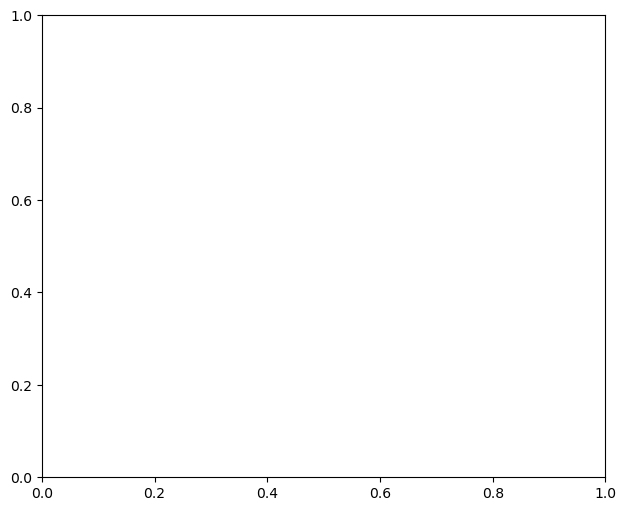

In [181]:
plt.figure(figsize=(16,6))

# Euclidean
plt.subplot(1,2,1)
sc1 = plt.scatter(
    embedding_euclidean[:,0],
    embedding_euclidean[:,1],
    c=df['Activity'],
    cmap='viridis',
    s=60,
    edgecolors='k',
    alpha=0.8
)
plt.title("UMAP - Euclidean")
plt.colorbar(sc1, label='Activity')

# Jaccard
plt.subplot(1,2,2)
sc2 = plt.scatter(
    embedding_jaccard[:,0],
    embedding_jaccard[:,1],
    c=df['Activity'],
    cmap='viridis',
    s=60,
    edgecolors='k',
    alpha=0.8
)
plt.title("UMAP - Jaccard")
plt.colorbar(sc2, label='Activity')

plt.tight_layout()
plt.show()


#### Compute Tanimoto Similarity Matrix

In [184]:
from rdkit import DataStructs
from rdkit.Chem import AllChem
import numpy as np

fp_rdkit = []

for mol in df['Molecule']:
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    fp_rdkit.append(fp)
n = len(fp_rdkit)
sim_matrix = np.zeros((n, n))

for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fp_rdkit[i], fp_rdkit)
    sim_matrix[i] = sims

print("Similarity matrix shape:", sim_matrix.shape)


Similarity matrix shape: (149, 149)


##### Step 1 — Extract Non-Diagonal Values

In [187]:
n = sim_matrix.shape[0]

upper_tri = sim_matrix[np.triu_indices(n, k=1)]

print("Mean similarity:", round(np.mean(upper_tri), 3))
print("Median similarity:", round(np.median(upper_tri), 3))
print("Max similarity (excluding self):", round(np.max(upper_tri), 3))
print("Min similarity:", round(np.min(upper_tri), 3))


Mean similarity: 0.26
Median similarity: 0.143
Max similarity (excluding self): 1.0
Min similarity: 0.044


###### Duplicate check

In [190]:
duplicates = np.where(sim_matrix == 1.0)
print(list(zip(duplicates[0], duplicates[1])))


[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5), (6, 6), (7, 7), (8, 8), (9, 9), (10, 10), (11, 11), (12, 12), (13, 13), (14, 14), (15, 15), (16, 16), (17, 17), (18, 18), (19, 19), (20, 20), (21, 21), (22, 22), (23, 23), (24, 24), (25, 25), (26, 26), (27, 27), (28, 28), (29, 29), (30, 30), (31, 31), (32, 32), (33, 33), (34, 34), (35, 35), (36, 36), (37, 37), (38, 38), (39, 39), (40, 40), (41, 41), (42, 42), (43, 43), (44, 44), (45, 45), (46, 46), (47, 47), (48, 48), (49, 49), (50, 50), (51, 51), (52, 52), (53, 53), (54, 54), (54, 55), (55, 54), (55, 55), (56, 56), (57, 57), (57, 58), (58, 57), (58, 58), (59, 59), (60, 60), (61, 61), (62, 62), (63, 63), (64, 64), (65, 65), (66, 66), (67, 67), (68, 68), (69, 69), (70, 70), (71, 71), (72, 72), (73, 73), (74, 74), (75, 75), (76, 76), (77, 77), (78, 78), (79, 79), (80, 80), (81, 81), (82, 82), (83, 83), (84, 84), (85, 85), (86, 86), (87, 87), (88, 88), (89, 89), (90, 90), (91, 91), (92, 92), (93, 93), (94, 94), (95, 95), (96, 96), (97, 97),

###### Confirm the duplicates (54, 55) & (57,58) 

In [193]:
print(df.loc[[54,55], ['Compound','SMILES','Activity']])
print(df.loc[[57,58], ['Compound','SMILES','Activity']])

   Compound                                             SMILES  Activity
54       36  S=C(C(S1)=NC2=C1C3=CC(OC)=CC=C3N=C2C)NC4=CC(C)...   3.60206
55       37  S=C(C(S1)=NC2=C1C3=CC(OC)=CC=C3N=C2C)NC4=CC(C)...   3.60206
   Compound                                             SMILES  Activity
57       42  O=C(NCC1=CC(C)=CC(C)=C1)COC2=CC(C)=NC3=CC=C(OC...  4.508638
58       45  O=C(NCC1=CC(C)=CC(C)=C1)COC2=CC(C)=NC3=CC=C(OC...  4.494850


###### Average duplicates

In [196]:
df = df.groupby('SMILES', as_index=False).agg({
    'Compound': 'first',
    'Activity': 'mean'
})


###### Collapse Duplicates by SMILES

In [199]:
df_clean = df.groupby('SMILES', as_index=False).agg({
    'Compound': 'first',
    'Activity': 'mean'
})


In [201]:
print("Original size:", len(df))
print("Cleaned size:", len(df_clean))


Original size: 147
Cleaned size: 147


In [203]:
df.to_csv("panS_dataset_curated.csv", index=False)


#### Recalculate Tanimoto for the cleaned dataset

##### Step 1 — Rebuild fingerprints from cleaned df

In [207]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np

# Ensure Molecule column exists
df['Molecule'] = df['SMILES'].apply(Chem.MolFromSmiles)

fp_rdkit = [
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    for mol in df['Molecule']
]


##### Step 2 — Recompute Tanimoto Matrix

In [210]:
n = len(fp_rdkit)
sim_matrix = np.zeros((n, n))

for i in range(n):
    sims = DataStructs.BulkTanimotoSimilarity(fp_rdkit[i], fp_rdkit)
    sim_matrix[i] = sims

print("New similarity matrix shape:", sim_matrix.shape)


New similarity matrix shape: (147, 147)


##### Step 3 — Recalculate Statistics

In [213]:
upper_tri = sim_matrix[np.triu_indices(n, k=1)]

print("Mean similarity:", round(np.mean(upper_tri), 3))
print("Median similarity:", round(np.median(upper_tri), 3))


Mean similarity: 0.26
Median similarity: 0.143


##### Step 4 - Save the dataset

In [216]:
np.save("PanS_tanimoto_matrix_147.npy", sim_matrix)

#### Calculate Structural Distance

##### Step 1 — Calculate Structural Distance

In [220]:
dist_matrix = 1 - sim_matrix

##### Step 2 — Quick Sanity Check

In [223]:
print("Min distance:", np.min(dist_matrix))
print("Max distance:", np.max(dist_matrix))


Min distance: 0.0
Max distance: 0.9555555555555556


##### Which Molecules Are They?

In [226]:
max_index = np.unravel_index(np.argmax(dist_matrix), dist_matrix.shape)

print("Indices of max distance pair:", max_index)
print("Distance value:", dist_matrix[max_index])


Indices of max distance pair: (137, 146)
Distance value: 0.9555555555555556


In [228]:
print(df.iloc[[137, 146]][['Compound', 'SMILES', 'Activity']])


    Compound                                             SMILES  Activity
137       6k  O=S(N1CCN(C2=NOC3=CC=CC(Cl)=C23)CC1)(C4=CC=C([...  3.927206
146       36  S=C(C(S1)=NC2=C1C3=CC(OC)=CC=C3N=C2C)NC4=CC(C)...  3.602060


#### Convert the matrices into pair-wise table for Cliff analysis

##### Step 1 — Recompute ΔActivity

In [232]:
import numpy as np

activity = df['Activity'].values
delta_activity = np.abs(activity[:, None] - activity[None, :])


##### Step 2 — Make Sure Distance Exists

In [235]:
dist_matrix = 1 - sim_matrix


##### Step 3 — Compute SALI

In [238]:
epsilon = 1e-5
sali_matrix = delta_activity / (dist_matrix + epsilon)


##### Step 4 — Build Pairwise Table

In [241]:
pairs = []
n = sim_matrix.shape[0]


In [243]:
for i in range(n):
    for j in range(i+1, n):
        pairs.append({
            "Mol1_Index": i,
            "Mol2_Index": j,
            "Mol1_Compound": df.iloc[i]['Compound'],
            "Mol2_Compound": df.iloc[j]['Compound'],
            "Similarity": sim_matrix[i, j],
            "Distance": dist_matrix[i, j],
            "Delta_pMIC": delta_activity[i, j],
            "SALI": sali_matrix[i, j]
        })

import pandas as pd
pairwise_df = pd.DataFrame(pairs)


###### Sanity Check

In [246]:
print(pairwise_df.shape)

(10731, 8)


###### Save It

In [249]:
pairwise_df.to_csv("PanS_pairwise_landscape.csv", index=False)


##### Top 10 Highest SALI Pairs (Strongest Cliffs)

In [252]:
pairwise_df.sort_values("SALI", ascending=False).head(10)


,Mol1_Index,Mol2_Index,Mol1_Compound,Mol2_Compound,Similarity,Distance,Delta_pMIC,SALI
9028,88,97,73,54,0.872340,0.127660,2.920819,22.877955
8461,79,88,1,73,0.875000,0.125000,2.420216,19.360182
9834,104,111,3l,3c,0.605263,0.394737,6.853872,17.362702
9836,104,113,3l,3a,0.592105,0.407895,7.013228,17.193299
10172,113,116,3a,7,0.590909,0.409091,7.013228,17.143028
7102,61,88,55,73,0.840000,0.160000,2.698970,16.867508
9031,88,100,73,49,0.854167,0.145833,2.397940,16.441890
10105,111,116,3c,7,0.582090,0.417910,6.853872,16.399944
9880,105,116,3g,7,0.573529,0.426471,6.886057,16.146237
9833,104,110,3l,3e,0.548780,0.451220,7.045757,15.614576


##### True Activity Cliffs (Strict Definition)

In [255]:
cliffs = pairwise_df[
    (pairwise_df["Similarity"] > 0.85) &
    (pairwise_df["Delta_pMIC"] > 1)
]

print("Number of strong cliffs:", len(cliffs))
cliffs.head()

Number of strong cliffs: 5


,Mol1_Index,Mol2_Index,Mol1_Compound,Mol2_Compound,Similarity,Distance,Delta_pMIC,SALI
8461,79,88,1,73,0.875000,0.125000,2.420216,19.360182
9028,88,97,73,54,0.872340,0.127660,2.920819,22.877955
9031,88,100,73,49,0.854167,0.145833,2.397940,16.441890
9456,96,97,65,54,0.877551,0.122449,1.301030,10.624211
9511,97,103,54,70,0.857143,0.142857,1.416363,9.913848


##### Visualize the Classic Activity Landscape Plot

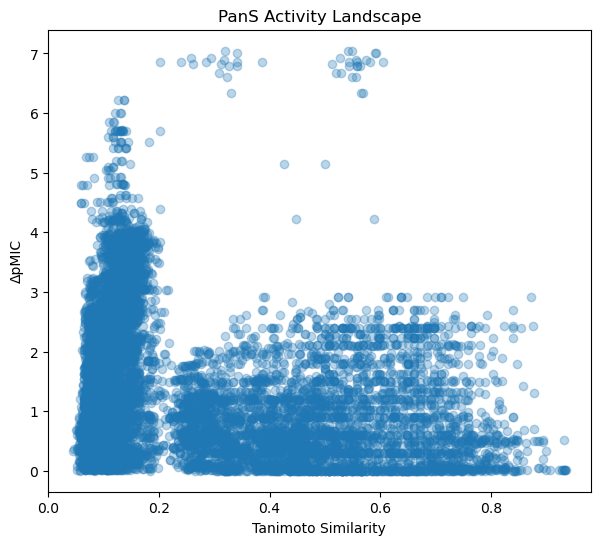

In [258]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))
plt.scatter(pairwise_df["Similarity"], 
            pairwise_df["Delta_pMIC"], 
            alpha=0.3)

plt.xlabel("Tanimoto Similarity")
plt.ylabel("ΔpMIC")
plt.title("PanS Activity Landscape")
plt.show()


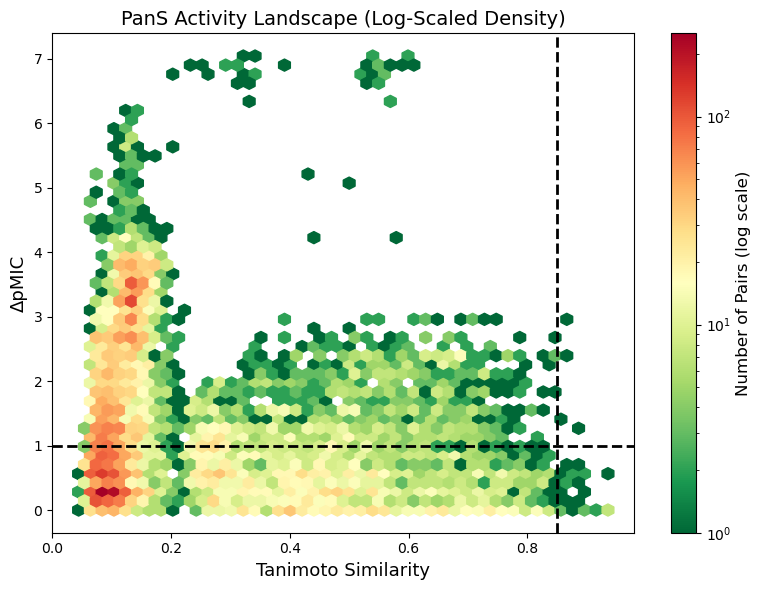

In [260]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(8,6))

hb = plt.hexbin(
    pairwise_df["Similarity"],
    pairwise_df["Delta_pMIC"],
    gridsize=45,
    cmap="RdYlGn_r",      # 👈 Green → Yellow → Red
    mincnt=1,
    norm=mcolors.LogNorm()
)

# Threshold lines
plt.axhline(1, linestyle="--", color="black", linewidth=2)
plt.axvline(0.85, linestyle="--", color="black", linewidth=2)

plt.xlabel("Tanimoto Similarity", fontsize=13)
plt.ylabel("ΔpMIC", fontsize=13)
plt.title("PanS Activity Landscape (Log-Scaled Density)", fontsize=14)

cb = plt.colorbar(hb)
cb.set_label("Number of Pairs (log scale)", fontsize=12)

plt.tight_layout()
plt.show()


##### Strict Activity Cliffs List

In [263]:
similarity_threshold = 0.85
activity_threshold = 1.0

strict_cliffs = pairwise_df[
    (pairwise_df["Similarity"] >= similarity_threshold) &
    (pairwise_df["Delta_pMIC"] >= activity_threshold)
].copy()

# Sort by SALI (strongest first)
strict_cliffs = strict_cliffs.sort_values("SALI", ascending=False)

strict_cliffs.reset_index(drop=True, inplace=True)

print(strict_cliffs)


   Mol1_Index  Mol2_Index Mol1_Compound Mol2_Compound  Similarity  Distance  \
0          88          97            73            54    0.872340  0.127660   
1          79          88             1            73    0.875000  0.125000   
2          88         100            73            49    0.854167  0.145833   
3          96          97            65            54    0.877551  0.122449   
4          97         103            54            70    0.857143  0.142857   

   Delta_pMIC       SALI  
0    2.920819  22.877955  
1    2.420216  19.360182  
2    2.397940  16.441890  
3    1.301030  10.624211  
4    1.416363   9.913848  


##### Save Strict Cliffs to File

In [266]:
strict_cliffs.to_csv("PanS_strict_activity_cliffs.csv", index=False)


##### Strong Cliffs List

In [269]:
strong_cliffs = pairwise_df[
    (pairwise_df["Similarity"] >= 0.85) &
    (pairwise_df["Delta_pMIC"] >= 2.0)
].copy()

strong_cliffs = strong_cliffs.sort_values("SALI", ascending=False)
strong_cliffs.reset_index(drop=True, inplace=True)

strong_cliffs.to_csv("PanS_strong_activity_cliffs.csv", index=False)

print(strong_cliffs)


   Mol1_Index  Mol2_Index Mol1_Compound Mol2_Compound  Similarity  Distance  \
0          88          97            73            54    0.872340  0.127660   
1          79          88             1            73    0.875000  0.125000   
2          88         100            73            49    0.854167  0.145833   

   Delta_pMIC       SALI  
0    2.920819  22.877955  
1    2.420216  19.360182  
2    2.397940  16.441890  


##### Moderate Cliffs List

In [272]:
moderate_cliffs = pairwise_df[
    (pairwise_df["Similarity"] >= 0.80) &
    (pairwise_df["Delta_pMIC"] >= 1.0)
].copy()

moderate_cliffs = moderate_cliffs.sort_values("SALI", ascending=False)
moderate_cliffs.reset_index(drop=True, inplace=True)

moderate_cliffs.to_csv("PanS_moderate_activity_cliffs.csv", index=False)

print(moderate_cliffs)


    Mol1_Index  Mol2_Index Mol1_Compound Mol2_Compound  Similarity  Distance  \
0           88          97            73            54    0.872340  0.127660   
1           79          88             1            73    0.875000  0.125000   
2           61          88            55            73    0.840000  0.160000   
3           88         100            73            49    0.854167  0.145833   
4           73          79            10             1    0.840000  0.160000   
5           60          88            57            73    0.840000  0.160000   
6           88          89            73            59    0.840000  0.160000   
7           79          80             1            16    0.823529  0.176471   
8           61          90            55            64    0.846154  0.153846   
9           88          94            73            66    0.803922  0.196078   
10          96          97            65            54    0.877551  0.122449   
11          88          99            73

###### Save Full Pairwise Landscape

In [275]:
pairwise_df.to_csv("PanS_full_pairwise_landscape.csv", index=False)


##### Save Strict Activity Cliffs

In [278]:
strict_cliffs.to_csv("PanS_strict_activity_cliffs.csv", index=False)


##### Save Strong Cliffs (ΔpMIC ≥ 2)

In [281]:
strong_cliffs.to_csv("PanS_strong_activity_cliffs.csv", index=False)


##### Save Moderate Cliffs

In [284]:
moderate_cliffs.to_csv("PanS_moderate_activity_cliffs.csv", index=False)


###### Save Everything in One Excel File

In [287]:
pairwise_df.to_csv("PanS_full_pairwise_landscape.csv", index=False)
strict_cliffs.to_csv("PanS_strict_cliffs.csv", index=False)
strong_cliffs.to_csv("PanS_strong_cliffs.csv", index=False)
moderate_cliffs.to_csv("PanS_moderate_cliffs.csv", index=False)


#### Visualizing Cliffs on Molecules

##### Step 1 — Recreate True Cliffs

In [291]:
similarity_threshold = 0.85
activity_threshold = 1.0

true_cliffs = pairwise_df[
    (pairwise_df["Similarity"] >= similarity_threshold) &
    (pairwise_df["Delta_pMIC"] >= activity_threshold)
].copy()

true_cliffs = true_cliffs.sort_values("SALI", ascending=False)
true_cliffs.reset_index(drop=True, inplace=True)

print("Number of strict cliffs:", len(true_cliffs))
true_cliffs


Number of strict cliffs: 5


,Mol1_Index,Mol2_Index,Mol1_Compound,Mol2_Compound,Similarity,Distance,Delta_pMIC,SALI
0,88,97,73,54,0.872340,0.127660,2.920819,22.877955
1,79,88,1,73,0.875000,0.125000,2.420216,19.360182
2,88,100,73,49,0.854167,0.145833,2.397940,16.441890
3,96,97,65,54,0.877551,0.122449,1.301030,10.624211
4,97,103,54,70,0.857143,0.142857,1.416363,9.913848


##### Step 2 — Make Sure Molecule Column Exists

In [294]:
from rdkit import Chem

df["Molecule"] = df["SMILES"].apply(Chem.MolFromSmiles)


##### Step 3 — Visualize Cliff Pairs

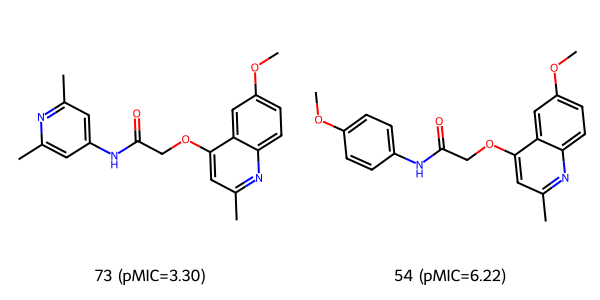

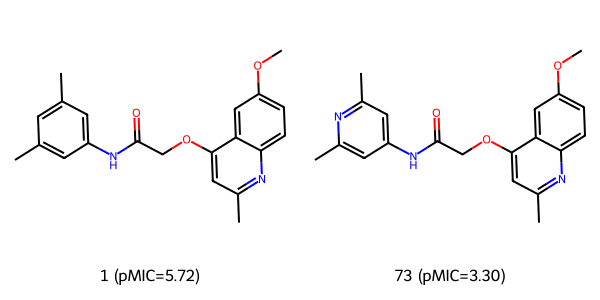

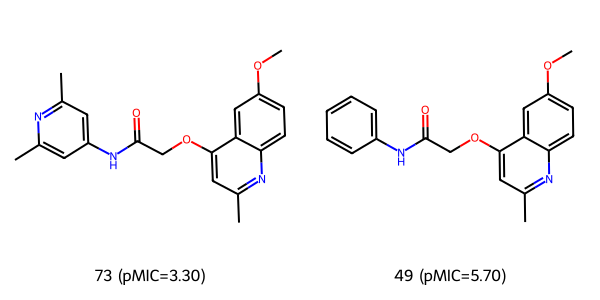

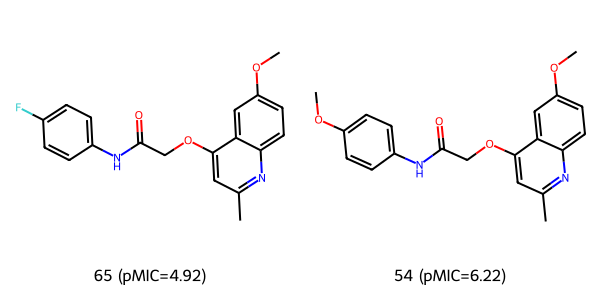

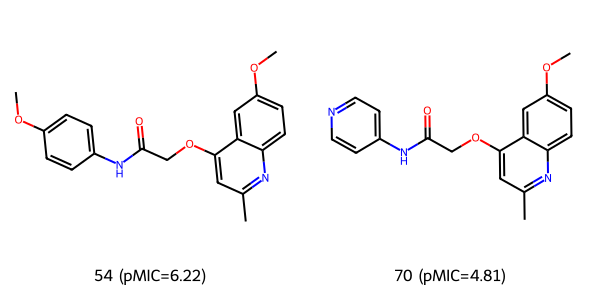

In [297]:
from rdkit.Chem import Draw
from IPython.display import display

for _, row in true_cliffs.iterrows():
    
    mol1 = df.iloc[int(row["Mol1_Index"])]["Molecule"]
    mol2 = df.iloc[int(row["Mol2_Index"])]["Molecule"]
    
    legend1 = f"{row['Mol1_Compound']} (pMIC={df.iloc[int(row['Mol1_Index'])]['Activity']:.2f})"
    legend2 = f"{row['Mol2_Compound']} (pMIC={df.iloc[int(row['Mol2_Index'])]['Activity']:.2f})"
    
    display(Draw.MolsToGridImage(
        [mol1, mol2],
        legends=[legend1, legend2],
        molsPerRow=2,
        subImgSize=(300,300)
    ))
true_cliffs["Mol1_SMILES"] = true_cliffs["Mol1_Index"].apply(lambda i: df.iloc[int(i)]["SMILES"])
true_cliffs["Mol2_SMILES"] = true_cliffs["Mol2_Index"].apply(lambda i: df.iloc[int(i)]["SMILES"])

true_cliffs.to_csv("PanS_strict_cliffs_with_SMILES.csv", index=False)


### Comparison of Full Dataset with Designed Compounds

#### Step 1 - Load Designed Compounds

In [301]:
syn = pd.read_csv(r"C:\Users\DELL\Prediction\Syn_cmpds.csv")
syn['mol'] = syn['SMILES'].apply(Chem.MolFromSmiles)


#### Step 2 — Generate Fingerprints for Designed Compounds

In [304]:
from rdkit.Chem import AllChem

syn_fp = [
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    for mol in syn['mol']
]


#### Step 3 — Compare Each New Compound to Dataset

In [307]:
from rdkit import DataStructs
import pandas as pd

comparison_results = []

# Loop through synthesized fingerprints
for i, fp in enumerate(syn_fp):

    # Compute similarity to known dataset
    similarities = DataStructs.BulkTanimotoSimilarity(fp, fp_rdkit)

    # Identify closest match
    max_similarity = max(similarities)
    max_index = similarities.index(max_similarity)

    comparison_results.append({
        "New_Compound_Index": i,
        "New_SMILES": syn.loc[i, "SMILES"],
        "Max_Similarity": round(max_similarity, 4),
        "Closest_Known_Compound": df.loc[max_index, "Compound"],
        "Closest_Known_pMIC": df.loc[max_index, "Activity"]
    })

# Create DataFrame
comparison_df = pd.DataFrame(comparison_results)

# Rank by similarity
comparison_df = comparison_df.sort_values(
    by="Max_Similarity",
    ascending=False
).reset_index(drop=True)

# Preview top 5
print(comparison_df.head())

# Save file
output_path = r"C:\Users\DELL\Prediction\Designed_vs_Known_Comparison.csv"
comparison_df.to_csv(output_path, index=False)

print(f"\nFile saved successfully at:\n{output_path}")


   New_Compound_Index                                    New_SMILES  \
0                  43  O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(OC)=CC=C32   
1                  42   O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=C(C)C=C32   
2                  44  O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=CC(OC)=C32   
3                  11      O=C(NC1=CC(OC)=CC=C1)COC2=NOC3=CC=CC=C32   
4                  40  O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(Cl)=CC=C32   

   Max_Similarity Closest_Known_Compound  Closest_Known_pMIC  
0          0.5500                     53             5.19382  
1          0.5323                     53             5.19382  
2          0.5246                     53             5.19382  
3          0.5246                     53             5.19382  
4          0.4923                     53             5.19382  

File saved successfully at:
C:\Users\DELL\Prediction\Designed_vs_Known_Comparison.csv


#### Evaluate Risk vs Potency Zone

##### STEP 1 — Visualize Similarity vs Reference Potency

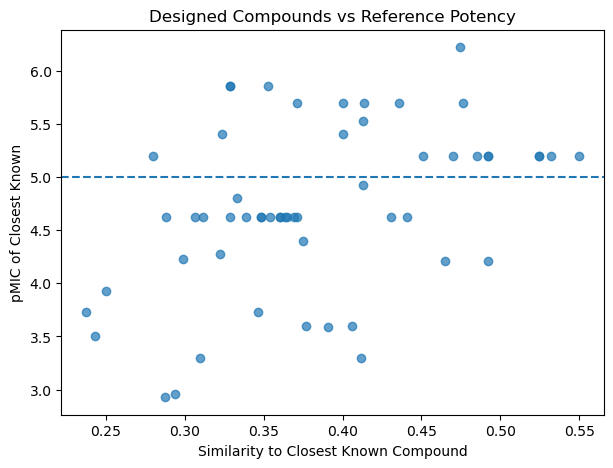

In [311]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    comparison_df["Max_Similarity"],
    comparison_df["Closest_Known_pMIC"],
    alpha=0.7
)

plt.xlabel("Similarity to Closest Known Compound")
plt.ylabel("pMIC of Closest Known")
plt.title("Designed Compounds vs Reference Potency")
plt.axhline(5, linestyle="--")   # potency threshold
plt.show()


##### color-coded Quadrant Plot (Much Clearer for Decision Making)

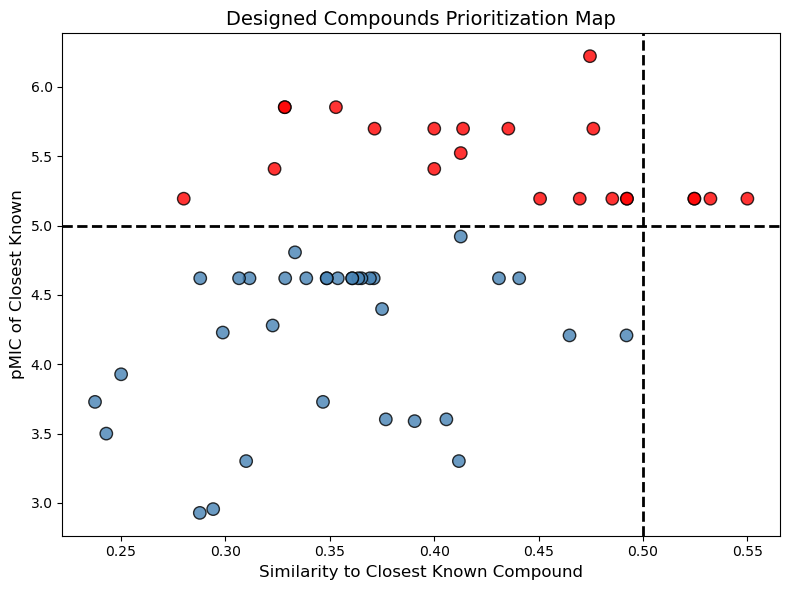

Red points = anchored to potent region
Blue = weaker region


In [314]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

# Color by potency
colors = np.where(
    comparison_df["Closest_Known_pMIC"] >= 5,
    "red",   # potent region
    "steelblue"
)

plt.scatter(
    comparison_df["Max_Similarity"],
    comparison_df["Closest_Known_pMIC"],
    c=colors,
    s=80,
    edgecolor="black",
    alpha=0.8
)

plt.axhline(5, linestyle="--", color="black", linewidth=2)
plt.axvline(0.5, linestyle="--", color="black", linewidth=2)

plt.xlabel("Similarity to Closest Known Compound", fontsize=12)
plt.ylabel("pMIC of Closest Known", fontsize=12)
plt.title("Designed Compounds Prioritization Map", fontsize=14)

plt.tight_layout()
plt.show()
print("Red points = anchored to potent region")
print("Blue = weaker region")


##### Bubble Plot (Similarity + Potency Combined)

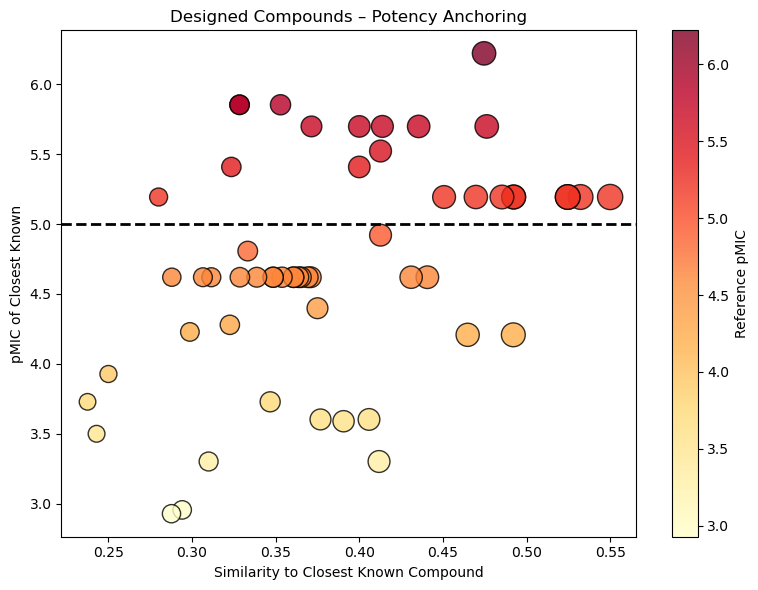

Larger bubble = more similar
Warmer color = more potent anchor


In [317]:
plt.figure(figsize=(8,6))

sizes = comparison_df["Max_Similarity"] * 600

plt.scatter(
    comparison_df["Max_Similarity"],
    comparison_df["Closest_Known_pMIC"],
    s=sizes,
    c=comparison_df["Closest_Known_pMIC"],
    cmap="YlOrRd",
    edgecolor="black",
    alpha=0.8
)

plt.axhline(5, linestyle="--", color="black", linewidth=2)

plt.xlabel("Similarity to Closest Known Compound")
plt.ylabel("pMIC of Closest Known")
plt.title("Designed Compounds – Potency Anchoring")

plt.colorbar(label="Reference pMIC")
plt.tight_layout()
plt.show()
print("Larger bubble = more similar")
print("Warmer color = more potent anchor")

##### Add Density Contours

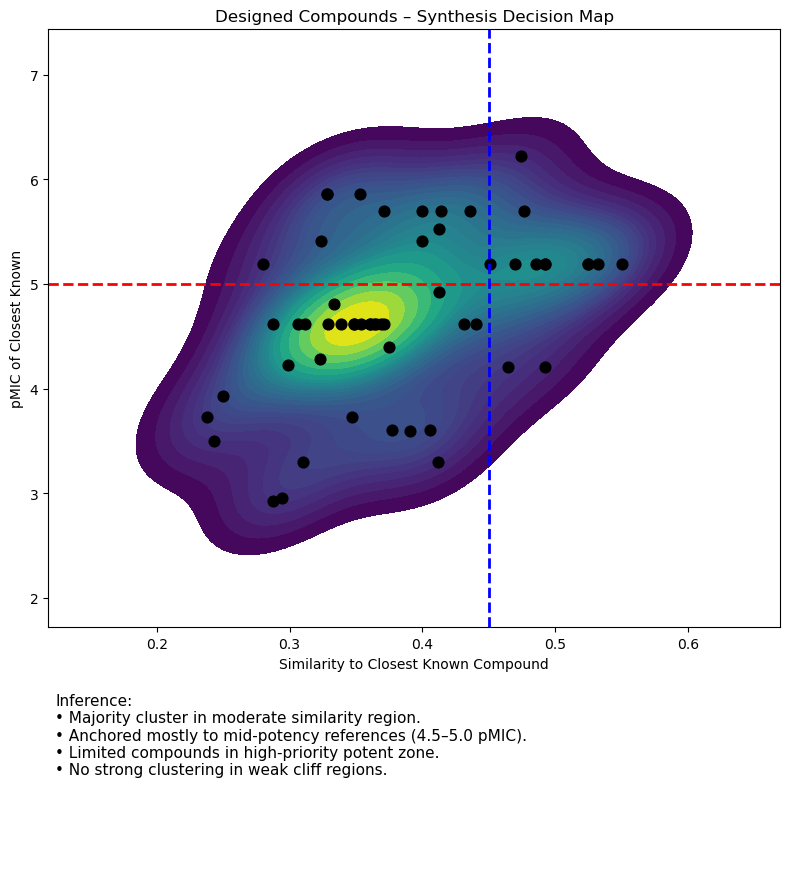

In [320]:
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(8,9),
    gridspec_kw={'height_ratios': [4, 1]}
)

# Plot
sns.kdeplot(
    x=comparison_df["Max_Similarity"],
    y=comparison_df["Closest_Known_pMIC"],
    fill=True,
    cmap="viridis",
    levels=25,
    thresh=0.05,
    ax=ax1
)

ax1.scatter(
    comparison_df["Max_Similarity"],
    comparison_df["Closest_Known_pMIC"],
    color="black",
    s=60
)

ax1.axhline(5, linestyle="--", color="red", linewidth=2)
ax1.axvline(0.45, linestyle="--", color="blue", linewidth=2)

ax1.set_xlabel("Similarity to Closest Known Compound")
ax1.set_ylabel("pMIC of Closest Known")
ax1.set_title("Designed Compounds – Synthesis Decision Map")

# Inference panel
ax2.axis("off")
ax2.text(
    0.01, 0.7,
    "Inference:\n"
    "• Majority cluster in moderate similarity region.\n"
    "• Anchored mostly to mid-potency references (4.5–5.0 pMIC).\n"
    "• Limited compounds in high-priority potent zone.\n"
    "• No strong clustering in weak cliff regions.",
    fontsize=11
)

plt.tight_layout()
plt.show()


### Comparison with Designed vs Strict Cliffs Only

#### Quick Cliff Risk Filter

##### STEP 1 — Reload Strict Cliff File

In [325]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs

# Load strict cliffs
strict_cliffs = pd.read_csv(
    r"C:\Users\DELL\Prediction\PanS_strict_cliffs_with_SMILES.csv"
)

strict_cliffs.head()


,Mol1_Index,Mol2_Index,Mol1_Compound,Mol2_Compound,Similarity,Distance,Delta_pMIC,SALI,Mol1_SMILES,Mol2_SMILES
0,88,97,73,54,0.872340,0.127660,2.920819,22.877955,O=C(NC1=CC(C)=NC(C)=C1)COC2=CC(C)=NC3=CC=C(OC)...,O=C(NC1=CC=C(OC)C=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23
1,79,88,1,73,0.875000,0.125000,2.420216,19.360182,O=C(NC1=CC(C)=CC(C)=C1)COC2=CC(C)=NC3=CC=C(OC)...,O=C(NC1=CC(C)=NC(C)=C1)COC2=CC(C)=NC3=CC=C(OC)...
2,88,100,73,49,0.854167,0.145833,2.397940,16.441890,O=C(NC1=CC(C)=NC(C)=C1)COC2=CC(C)=NC3=CC=C(OC)...,O=C(NC1=CC=CC=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23
3,96,97,65,54,0.877551,0.122449,1.301030,10.624211,O=C(NC1=CC=C(F)C=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23,O=C(NC1=CC=C(OC)C=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23
4,97,103,54,70,0.857143,0.142857,1.416363,9.913848,O=C(NC1=CC=C(OC)C=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23,O=C(NC1=CC=NC=C1)COC2=CC(C)=NC3=CC=C(OC)C=C23


##### STEP 2 — Extract Unique Cliff SMILES

In [328]:
cliff_smiles = set(strict_cliffs["Mol1_SMILES"]).union(
    set(strict_cliffs["Mol2_SMILES"])
)

cliff_smiles = list(cliff_smiles)

len(cliff_smiles)


6

##### STEP 3 — Convert Cliff Molecules to RDKit + Fingerprints

In [331]:
cliff_mols = [Chem.MolFromSmiles(smi) for smi in cliff_smiles]

cliff_fp = [
    AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    for mol in cliff_mols
]


##### STEP 4 — Compute Similarity of Designed Compounds to Cliff Molecules

In [334]:
cliff_similarity_results = []

for i, fp in enumerate(syn_fp):
    sims = DataStructs.BulkTanimotoSimilarity(fp, cliff_fp)
    max_sim = max(sims)

    cliff_similarity_results.append({
        "New_Index": i,
        "Max_Cliff_Similarity": round(max_sim, 4)
    })

cliff_similarity_df = pd.DataFrame(cliff_similarity_results)


##### STEP 5 — Quick Cliff Risk Filter

In [337]:
cliff_risk = cliff_similarity_df[
    cliff_similarity_df["Max_Cliff_Similarity"] > 0.75
]

cliff_risk

print ("No designed compound has similarity > 0.75 to any strict cliff molecule")

No designed compound has similarity > 0.75 to any strict cliff molecule


### Cross-validation of the Comparisons of designed molecules with reported inhibitors

##### STEP 1 - Load the molecules

In [341]:
from rdkit import Chem

# Ensure molecules exist
syn["mol"] = syn["SMILES"].apply(Chem.MolFromSmiles)
df["Molecule"] = df["SMILES"].apply(Chem.MolFromSmiles)


##### STEP 2 — Recreate Top 10 From Similarity Anchoring

In [344]:
top10 = comparison_df.sort_values(
    "Max_Similarity",
    ascending=False
).head(10).reset_index(drop=True)

top10


,New_Compound_Index,New_SMILES,Max_Similarity,Closest_Known_Compound,Closest_Known_pMIC
0,43,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(OC)=CC=C32,0.5500,53,5.193820
1,42,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=C(C)C=C32,0.5323,53,5.193820
2,44,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=CC(OC)=C32,0.5246,53,5.193820
3,11,O=C(NC1=CC(OC)=CC=C1)COC2=NOC3=CC=CC=C32,0.5246,53,5.193820
4,40,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(Cl)=CC=C32,0.4923,53,5.193820
5,46,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(N)=CC=C32,0.4923,53,5.193820
6,18,O=C(NC1=CC(OC)=C(OC)C(OC)=C1)COC2=NOC3=CC=CC=C32,0.4921,64,4.207608
7,41,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC([N+]([O-])=O...,0.4853,53,5.193820
8,14,O=C(NC1=CC(C)=CC=C1)COC2=NOC3=CC=CC=C32,0.4762,50,5.698970
9,4,O=C(NC1=CC=C(OC)C=C1)COC2=NOC3=CC=CC=C32,0.4746,54,6.221849


##### STEP 3 — Side-by-Side Visualization (Clean & Clear)

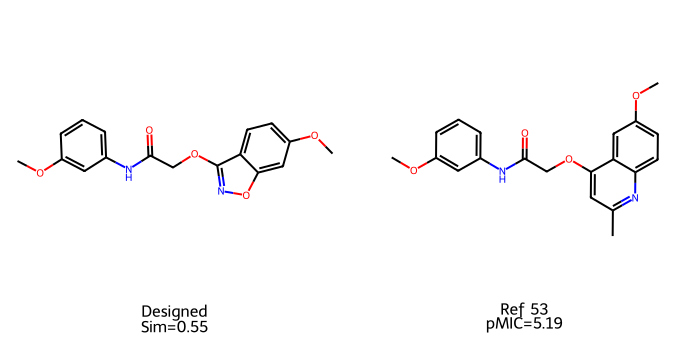

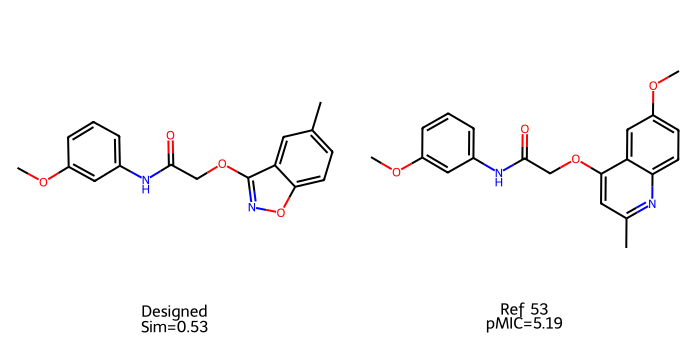

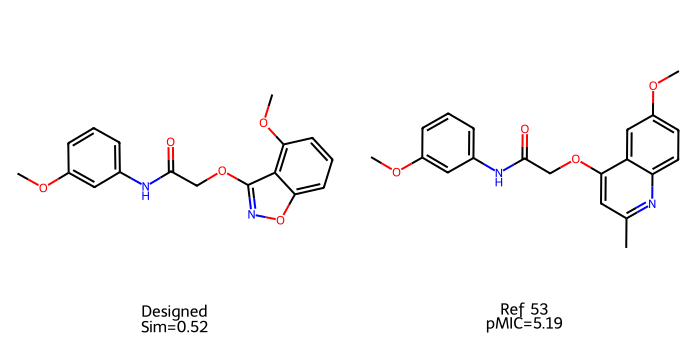

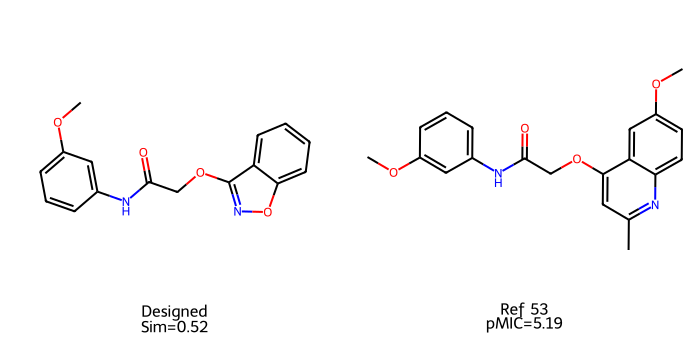

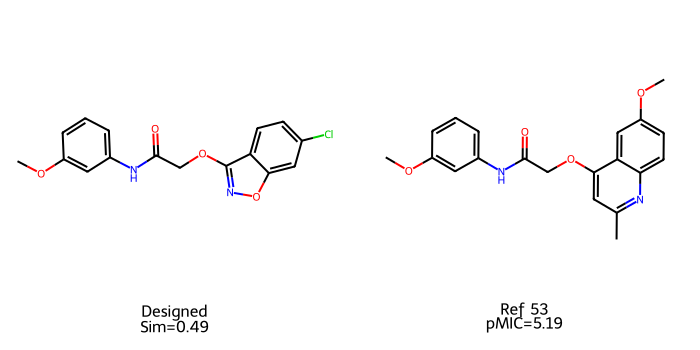

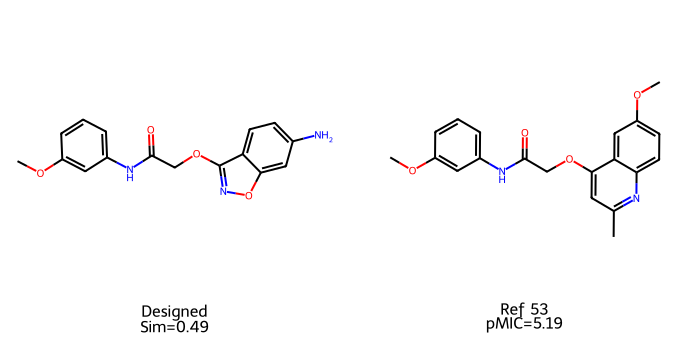

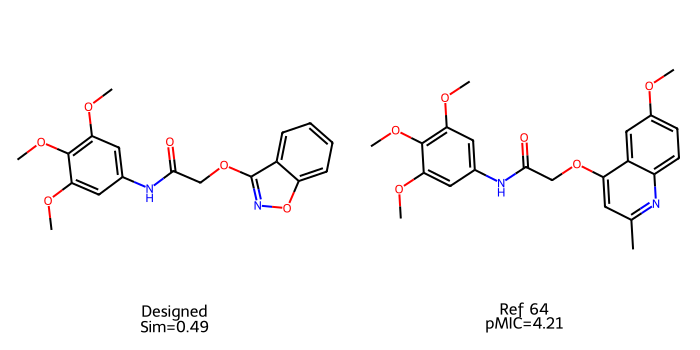

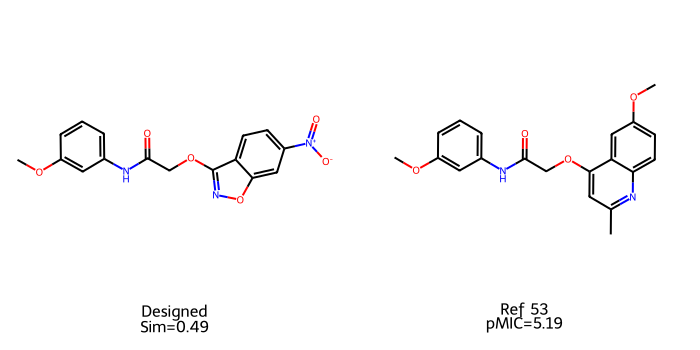

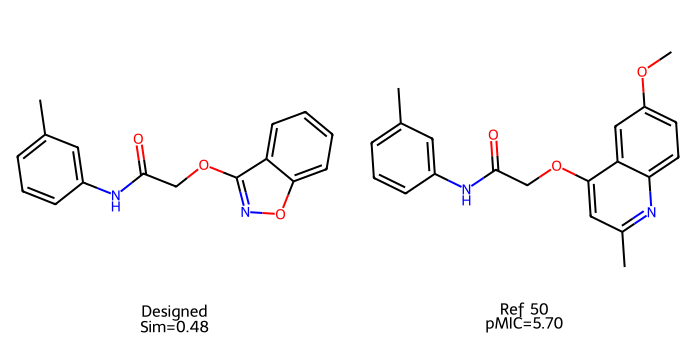

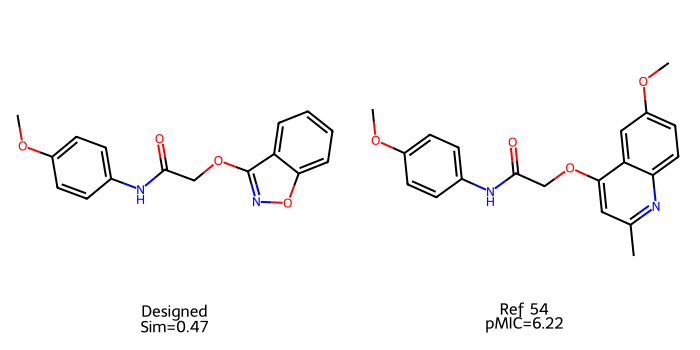

In [347]:
from rdkit.Chem import Draw
from IPython.display import display

for _, row in top10.iterrows():

    new_mol = syn.loc[row["New_Compound_Index"], "mol"]
    
    ref_mol = df[df["Compound"] == row["Closest_Known_Compound"]]["Molecule"].values[0]
    
    display(Draw.MolsToGridImage(
        [new_mol, ref_mol],
        legends=[
            f"Designed\nSim={row['Max_Similarity']:.2f}",
            f"Ref {row['Closest_Known_Compound']}\npMIC={row['Closest_Known_pMIC']:.2f}"
        ],
        molsPerRow=2,
        subImgSize=(350,350)
    ))


##### STEP 4 — Save Comparison Image and comparison table

In [350]:
# STEP 1 — Extract Top1 Row
top1 = top10.loc[0]

new_idx = top1["New_Compound_Index"]
ref_name = top1["Closest_Known_Compound"]

new_mol = syn.loc[new_idx, "mol"]
ref_mol = df[df["Compound"] == ref_name]["Molecule"].values[0]


In [352]:
# STEP 2 — Save Image
from rdkit.Chem import Draw
from PIL import Image

img1 = Draw.MolToImage(new_mol, size=(400,400))
img2 = Draw.MolToImage(ref_mol, size=(400,400))

combined = Image.new('RGB', (800, 400))
combined.paste(img1, (0,0))
combined.paste(img2, (400,0))

combined.save(r"C:\Users\DELL\Prediction\Top1_vs_Known.png")


In [354]:
# STEP 3 — Save Comparison Table
comparison_record = pd.DataFrame({
    "New_Compound_Index": [new_idx],
    "New_SMILES": [top1["New_SMILES"]],
    "Max_Similarity": [top1["Max_Similarity"]],
    "Closest_Known_Compound": [ref_name],
    "Closest_Known_pMIC": [top1["Closest_Known_pMIC"]],
    "Closest_Known_SMILES": [
        df[df["Compound"] == ref_name]["SMILES"].values[0]
    ]
})

comparison_record.to_csv(
    r"C:\Users\DELL\Prediction\Top1_vs_Known_Comparison.csv",
    index=False
)


### Structural Comparison

#### STEP 1 — Highlight Common Core (MCS-Based Comparison)

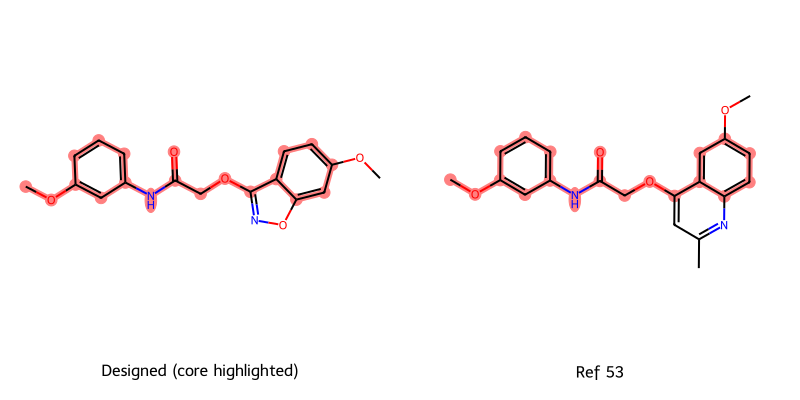

In [358]:
from rdkit.Chem import rdFMCS
from rdkit.Chem import Draw

# Take top1 example
top1 = top10.loc[0]

new_mol = syn.loc[top1["New_Compound_Index"], "mol"]
ref_name = top1["Closest_Known_Compound"]
ref_mol = df[df["Compound"] == ref_name]["Molecule"].values[0]

# Find Maximum Common Substructure
mcs = rdFMCS.FindMCS([new_mol, ref_mol])
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

# Highlight shared atoms
img = Draw.MolsToGridImage(
    [new_mol, ref_mol],
    highlightAtomLists=[
        new_mol.GetSubstructMatch(mcs_mol),
        ref_mol.GetSubstructMatch(mcs_mol)
    ],
    legends=["Designed (core highlighted)", f"Ref {ref_name}"],
    molsPerRow=2,
    subImgSize=(400,400)
)

img


#### STEP 2 — Loop for All Top 10 With IDs

In [361]:
from rdkit.Chem import rdFMCS, Draw
from rdkit import Chem
from PIL import Image, ImageDraw, ImageFont
import os
import re

output_folder = r"C:\Users\DELL\Prediction\Top10_Structural_Comparison"
os.makedirs(output_folder, exist_ok=True)

for i, row in top10.iterrows():

    new_idx = row["New_Compound_Index"]
    ref_name = row["Closest_Known_Compound"]

    new_mol = syn.loc[new_idx, "mol"]
    ref_mol = df[df["Compound"] == ref_name]["Molecule"].values[0]

    if new_mol is None or ref_mol is None:
        print(f"Skipping {new_idx}")
        continue

    # Find MCS
    mcs = rdFMCS.FindMCS([new_mol, ref_mol])
    if not mcs.smartsString:
        print(f"No MCS for {new_idx}")
        continue

    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

    new_match = new_mol.GetSubstructMatch(mcs_mol)
    ref_match = ref_mol.GetSubstructMatch(mcs_mol)

    # Generate individual molecule images (PIL guaranteed)
    img1 = Draw.MolToImage(new_mol, size=(400, 400), highlightAtoms=new_match)
    img2 = Draw.MolToImage(ref_mol, size=(400, 400), highlightAtoms=ref_match)

    # Create blank canvas for side-by-side image
    combined = Image.new("RGB", (800, 450), "white")
    combined.paste(img1, (0, 0))
    combined.paste(img2, (400, 0))

    # Add legends manually
    draw = ImageDraw.Draw(combined)

    legend1 = f"Designed ID: {new_idx} | Sim = {row['Max_Similarity']:.2f}"
    legend2 = f"Reference: {ref_name} | pMIC = {row['Closest_Known_pMIC']:.2f}"

    draw.text((10, 410), legend1, fill="black")
    draw.text((410, 410), legend2, fill="black")

    # Clean filename
    safe_ref_name = re.sub(r'[\\/*?:"<>|]', "", str(ref_name))
    file_name = f"Comparison_{new_idx}_vs_{safe_ref_name}.png"
    save_path = os.path.join(output_folder, file_name)

    # Save safely (this WILL work)
    combined.save(save_path)

    print(f"Saved: {file_name}")

print("\nAll Top 10 comparisons saved successfully.")


Saved: Comparison_43_vs_53.png
Saved: Comparison_42_vs_53.png
Saved: Comparison_44_vs_53.png
Saved: Comparison_11_vs_53.png
Saved: Comparison_40_vs_53.png
Saved: Comparison_46_vs_53.png
Saved: Comparison_18_vs_64.png
Saved: Comparison_41_vs_53.png
Saved: Comparison_14_vs_50.png
Saved: Comparison_4_vs_54.png

All Top 10 comparisons saved successfully.


##### Generate Comparison Table

In [364]:
import pandas as pd

comparison_rows = []

for i, row in top10.iterrows():

    new_idx = row["New_Compound_Index"]
    ref_name = row["Closest_Known_Compound"]

    reference_pmic = row["Closest_Known_pMIC"]
    similarity = row["Max_Similarity"]

    # SAR classification without prediction
    if similarity > 0.7:
        region = "High Structural Proximity"
    elif similarity > 0.5:
        region = "Moderate Analog"
    else:
        region = "Distant Analog"

    comparison_rows.append([
        new_idx,
        ref_name,
        round(similarity, 3),
        round(reference_pmic, 3),
        region
    ])

comparison_table = pd.DataFrame(
    comparison_rows,
    columns=[
        "Designed_ID",
        "Reference_ID",
        "Similarity",
        "Reference_pMIC",
        "SAR_Region"
    ]
)

comparison_table
save_path = r"C:\Users\DELL\Prediction\Top10_SAR_Comparison_Table.csv"

comparison_table.to_csv(save_path, index=False)

print("Top 10 SAR comparison table saved successfully.")



Top 10 SAR comparison table saved successfully.


### Core vs Substitution Highlighting

##### Single Pair Core vs Substitution Highlight

Image saved successfully.


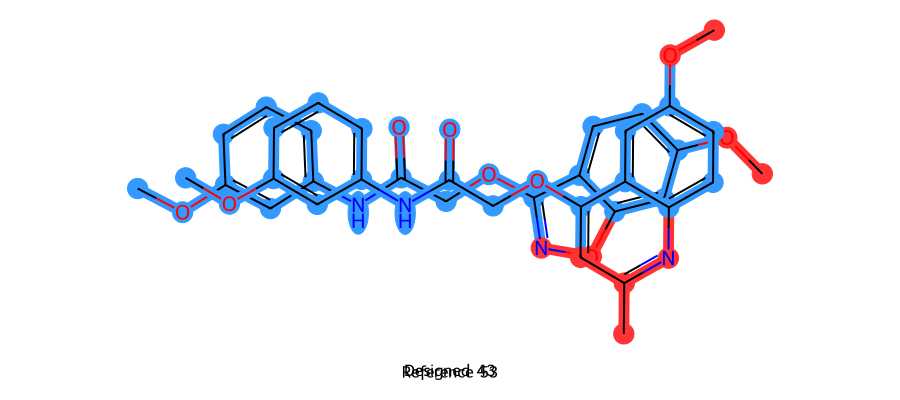

In [368]:
from rdkit import Chem
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display

# Example: first compound
row = top10.iloc[0]

new_idx = row["New_Compound_Index"]
ref_name = row["Closest_Known_Compound"]

new_mol = syn.loc[new_idx, "mol"]
ref_mol = df[df["Compound"] == ref_name]["Molecule"].values[0]

# -------------------------
# Find MCS (core)
# -------------------------
mcs = rdFMCS.FindMCS([new_mol, ref_mol])
mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

new_core = new_mol.GetSubstructMatch(mcs_mol)
ref_core = ref_mol.GetSubstructMatch(mcs_mol)

# Substitution atoms
new_subs = [i for i in range(new_mol.GetNumAtoms()) if i not in new_core]
ref_subs = [i for i in range(ref_mol.GetNumAtoms()) if i not in ref_core]

# -------------------------
# Highlight settings
# -------------------------
highlight_atoms = [
    list(new_core) + new_subs,
    list(ref_core) + ref_subs
]

highlight_colors = [
    {**{idx:(0.2,0.6,1.0) for idx in new_core},    # Blue core
     **{idx:(1.0,0.2,0.2) for idx in new_subs}},  # Red substitution
    
    {**{idx:(0.2,0.6,1.0) for idx in ref_core},
     **{idx:(1.0,0.2,0.2) for idx in ref_subs}}
]

# -------------------------
# Draw
# -------------------------
drawer = rdMolDraw2D.MolDraw2DCairo(900, 400)

drawer.DrawMolecules(
    [new_mol, ref_mol],
    highlightAtoms=highlight_atoms,
    highlightAtomColors=highlight_colors,
    legends=[
        f"Designed {new_idx}",
        f"Reference {ref_name}"
    ]
)

drawer.FinishDrawing()

png = drawer.GetDrawingText()

# -------------------------
# Save image
# -------------------------
save_path = r"C:\Users\DELL\Prediction\Core_vs_Substitution_Test.png"

with open(save_path, "wb") as f:
    f.write(png)

print("Image saved successfully.")

# -------------------------
# Display image in notebook
# -------------------------
display(Image(png))



Designed 43 vs Reference 53
Similarity: 0.55 | Ref pMIC: 5.19


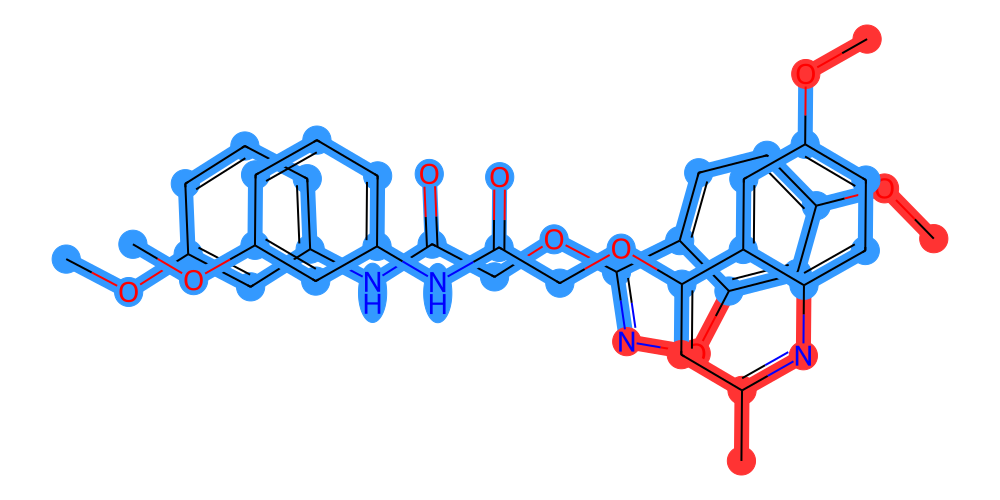


Designed 42 vs Reference 53
Similarity: 0.53 | Ref pMIC: 5.19


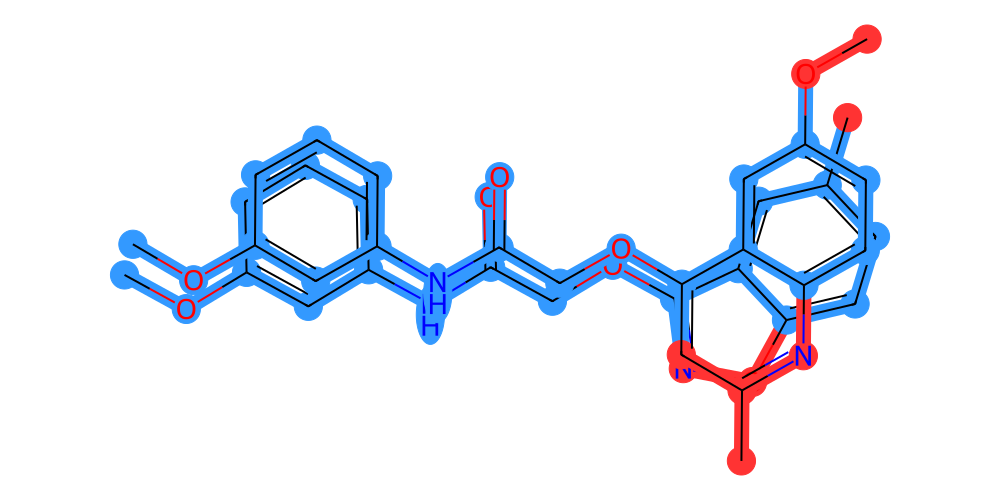


Designed 44 vs Reference 53
Similarity: 0.52 | Ref pMIC: 5.19


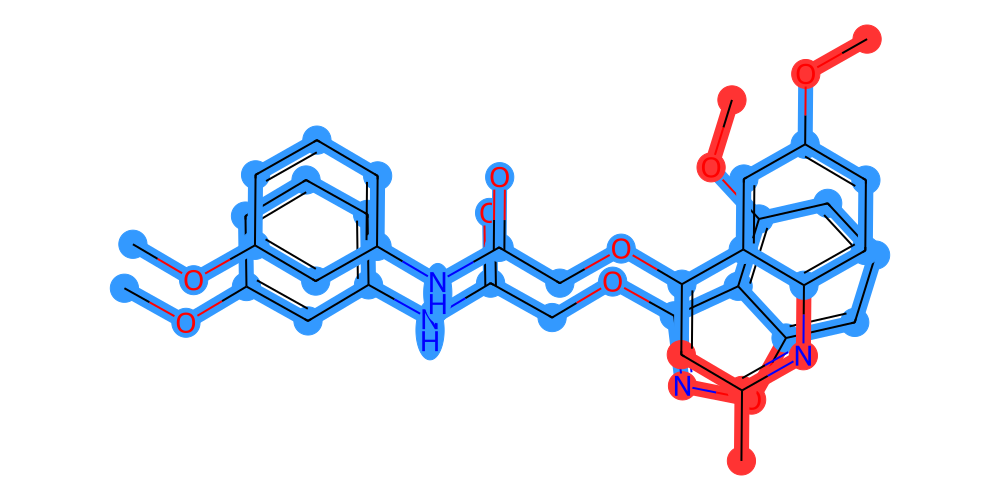


Designed 11 vs Reference 53
Similarity: 0.52 | Ref pMIC: 5.19


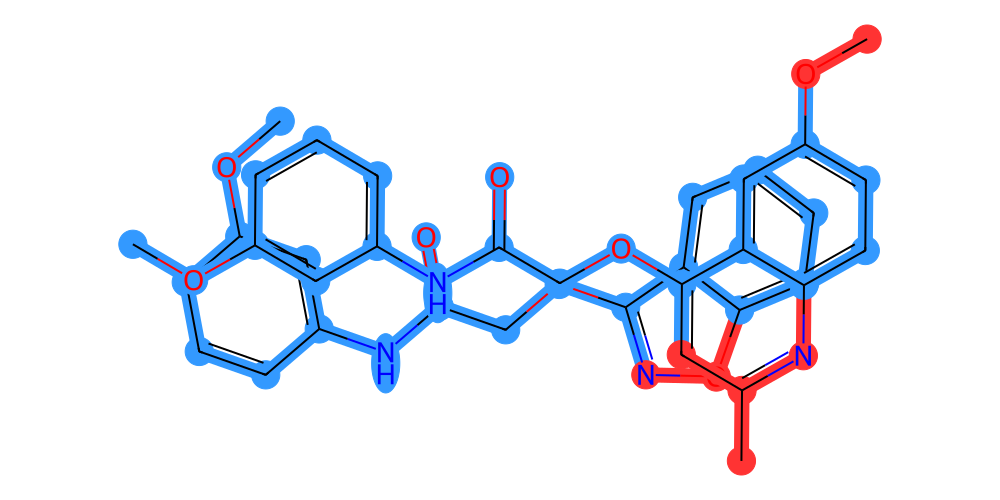


Designed 40 vs Reference 53
Similarity: 0.49 | Ref pMIC: 5.19


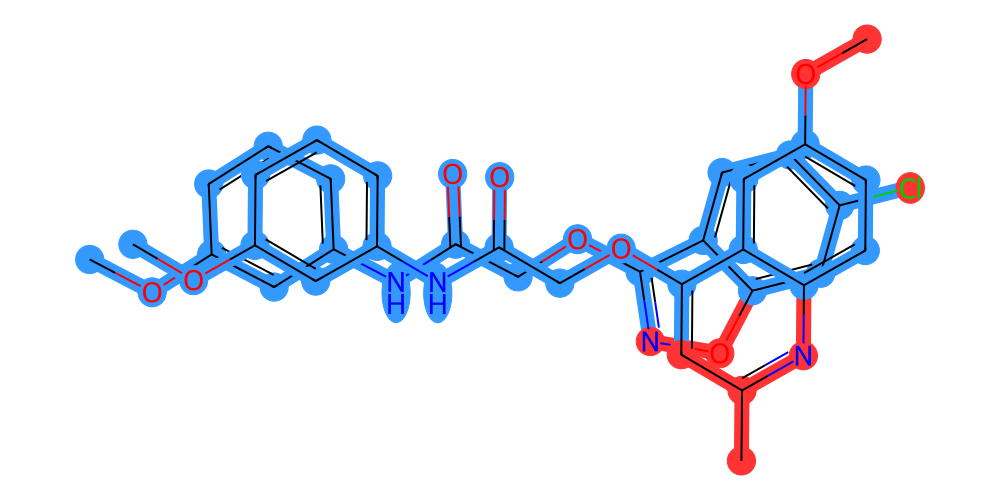


Designed 46 vs Reference 53
Similarity: 0.49 | Ref pMIC: 5.19


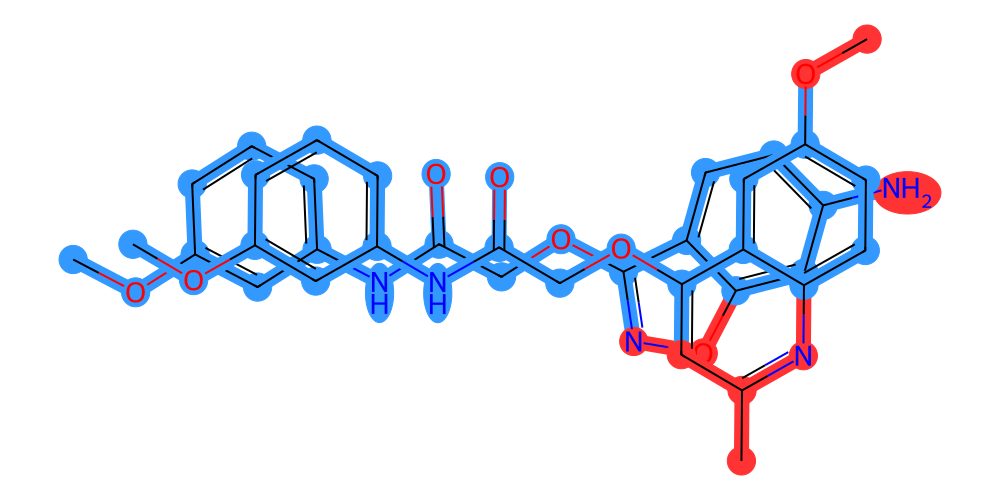


Designed 18 vs Reference 64
Similarity: 0.49 | Ref pMIC: 4.21


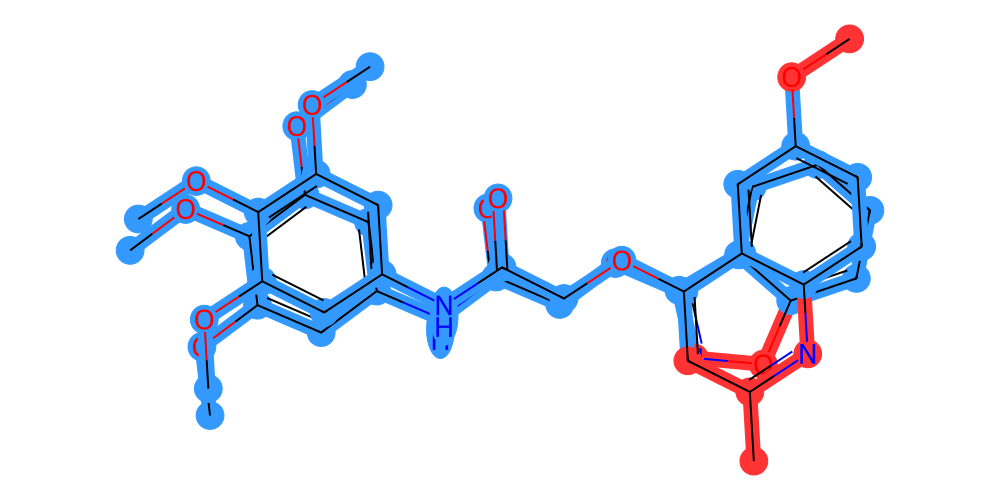


Designed 41 vs Reference 53
Similarity: 0.49 | Ref pMIC: 5.19


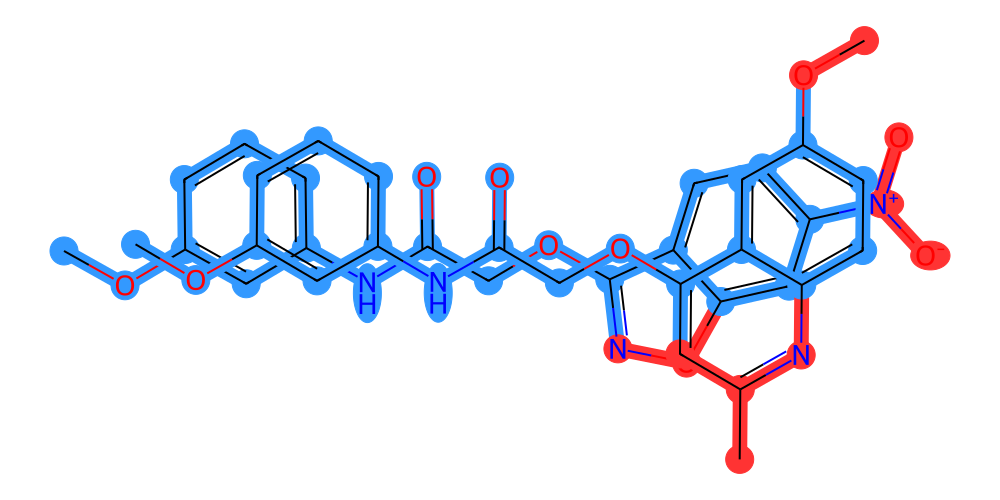


Designed 14 vs Reference 50
Similarity: 0.48 | Ref pMIC: 5.70


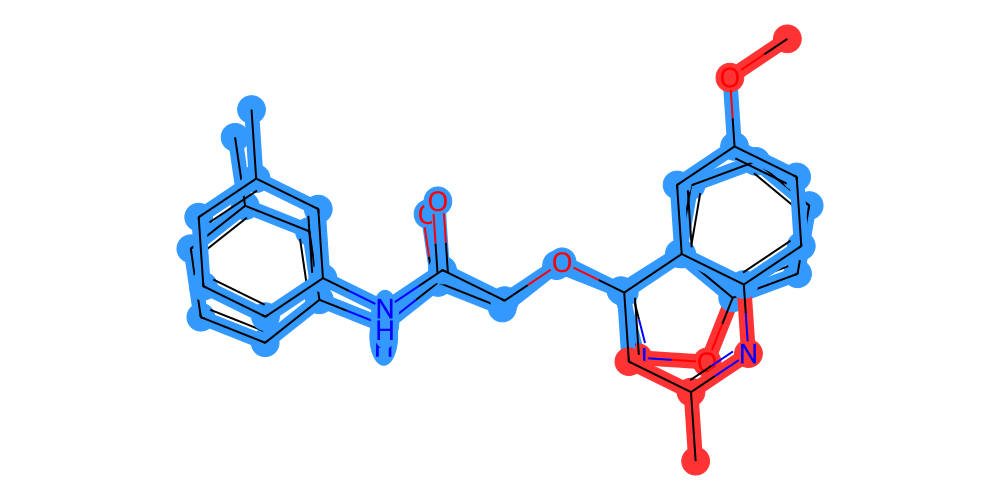


Designed 4 vs Reference 54
Similarity: 0.47 | Ref pMIC: 6.22


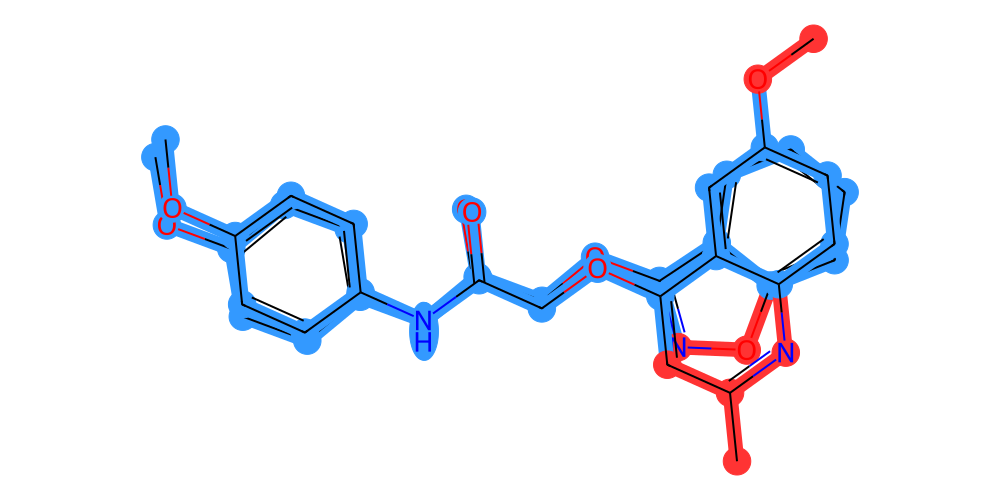


All clean structural images generated.


In [370]:
from rdkit import Chem
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import Image, display
import os
import re

output_folder = r"C:\Users\DELL\Prediction\Core_vs_Substitution_Top10_Clean"
os.makedirs(output_folder, exist_ok=True)

for i, row in top10.iterrows():

    new_idx = row["New_Compound_Index"]
    ref_name = row["Closest_Known_Compound"]

    new_mol = syn.loc[new_idx, "mol"]
    ref_mol = df[df["Compound"] == ref_name]["Molecule"].values[0]

    if new_mol is None or ref_mol is None:
        continue

    mcs = rdFMCS.FindMCS([new_mol, ref_mol])
    if not mcs.smartsString:
        continue

    mcs_mol = Chem.MolFromSmarts(mcs.smartsString)

    new_core = new_mol.GetSubstructMatch(mcs_mol)
    ref_core = ref_mol.GetSubstructMatch(mcs_mol)

    new_subs = [i for i in range(new_mol.GetNumAtoms()) if i not in new_core]
    ref_subs = [i for i in range(ref_mol.GetNumAtoms()) if i not in ref_core]

    highlight_atoms = [
        list(new_core) + new_subs,
        list(ref_core) + ref_subs
    ]

    highlight_colors = [
        {**{idx:(0.2,0.6,1.0) for idx in new_core},
         **{idx:(1.0,0.2,0.2) for idx in new_subs}},
        
        {**{idx:(0.2,0.6,1.0) for idx in ref_core},
         **{idx:(1.0,0.2,0.2) for idx in ref_subs}}
    ]

    drawer = rdMolDraw2D.MolDraw2DCairo(1000, 500)

    drawer.DrawMolecules(
        [new_mol, ref_mol],
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_colors
    )

    drawer.FinishDrawing()
    png = drawer.GetDrawingText()

    safe_ref_name = re.sub(r'[\\/*?:"<>|]', "", str(ref_name))
    file_name = f"CoreSub_{new_idx}_vs_{safe_ref_name}.png"
    save_path = os.path.join(output_folder, file_name)

    with open(save_path, "wb") as f:
        f.write(png)

    print(f"\nDesigned {new_idx} vs Reference {ref_name}")
    print(f"Similarity: {row['Max_Similarity']:.2f} | Ref pMIC: {row['Closest_Known_pMIC']:.2f}")

    display(Image(data=png, width=900))

print("\nAll clean structural images generated.")


#### Shortlist Molecules for Synthesis

##### STEP 1 — Physicochemical Properties

In [414]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Crippen, rdMolDescriptors
import pandas as pd

shortlist_ids = [43, 42, 44, 11, 40, 46, 18, 41, 14, 4]

prop_rows = []

for idx in shortlist_ids:
    
    mol = syn.loc[idx, "mol"]
    smi = syn.loc[idx, "SMILES"]
    
    mw = Descriptors.MolWt(mol)
    logp = Crippen.MolLogP(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd = Lipinski.NumHDonors(mol)
    hba = Lipinski.NumHAcceptors(mol)
    rot = Lipinski.NumRotatableBonds(mol)
    
    prop_rows.append([
        idx, smi, round(mw,2), round(logp,2),
        round(tpsa,2), hbd, hba, rot
    ])

physchem_df = pd.DataFrame(
    prop_rows,
    columns=["ID","SMILES","MW","LogP","TPSA","HBD","HBA","RotBonds"]
)

physchem_df

save_path = r"C:\Users\DELL\Prediction\Shortlist_Physicochemical_Profile.csv"

physchem_df.to_csv(save_path, index=False)

print("Physicochemical profile saved successfully.")


Physicochemical profile saved successfully.


##### STEP 2 — Lipinski Rule Check

In [417]:
def lipinski_pass(row):
    violations = 0
    if row["MW"] > 500: violations += 1
    if row["LogP"] > 5: violations += 1
    if row["HBD"] > 5: violations += 1
    if row["HBA"] > 10: violations += 1
    return "Pass" if violations <= 1 else "Fail"

physchem_df["Lipinski"] = physchem_df.apply(lipinski_pass, axis=1)

physchem_df
save_path = r"C:\Users\DELL\Prediction\Shortlist_Physicochemical_Profile_With_Lipinski.csv"

physchem_df.to_csv(save_path, index=False)

print("Updated physicochemical profile with Lipinski results saved successfully.")

Updated physicochemical profile with Lipinski results saved successfully.


##### STEP 3 — PAINS Filter

In [420]:
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)

catalog = FilterCatalog(params)

pains_results = []

for idx in shortlist_ids:
    
    mol = syn.loc[idx, "mol"]
    
    entry = catalog.GetFirstMatch(mol)
    
    if entry is None:
        pains_results.append("Clean")
    else:
        pains_results.append(entry.GetDescription())

physchem_df["PAINS"] = pains_results

physchem_df
save_path = r"C:\Users\DELL\Prediction\Shortlist_Physchem_Lipinski_PAINS.csv"

physchem_df.to_csv(save_path, index=False)

print("Updated file with PAINS results saved successfully.")


Updated file with PAINS results saved successfully.


##### STEP 4 — Synthetic Accessibility Score (SA Score)

In [425]:
from rdkit.Chem import rdMolDescriptors

complexity_scores = []

for idx in shortlist_ids:
    mol = syn.loc[idx, "mol"]
    
    rings = rdMolDescriptors.CalcNumRings(mol)
    aromatic = rdMolDescriptors.CalcNumAromaticRings(mol)
    spiro = rdMolDescriptors.CalcNumSpiroAtoms(mol)
    bridge = rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    heavy = mol.GetNumHeavyAtoms()
    rot = rdMolDescriptors.CalcNumRotatableBonds(mol)
    
    # Composite complexity formula
    score = (
        rings * 1.5 +
        aromatic * 1.2 +
        spiro * 2 +
        bridge * 2 +
        rot * 0.5 +
        heavy * 0.1
    )
    
    complexity_scores.append(round(score, 2))

physchem_df["Synthetic_Complexity_Index"] = complexity_scores

physchem_df


,ID,SMILES,MW,LogP,TPSA,HBD,HBA,RotBonds,Lipinski,PAINS,Synthetic_Complexity_Index
0,43,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(OC)=CC=C32,328.32,2.86,82.82,1,6,6,Pass,Clean,13.5
1,42,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=C(C)C=C32,312.33,3.16,73.59,1,5,5,Pass,Clean,12.9
2,44,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC=CC(OC)=C32,328.32,2.86,82.82,1,6,6,Pass,Clean,13.5
3,11,O=C(NC1=CC(OC)=CC=C1)COC2=NOC3=CC=CC=C32,298.30,2.85,73.59,1,5,5,Pass,Clean,12.8
4,40,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(Cl)=CC=C32,332.74,3.51,73.59,1,5,5,Pass,Clean,12.9
5,46,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC(N)=CC=C32,313.31,2.44,99.61,2,6,5,Pass,Clean,12.9
6,18,O=C(NC1=CC(OC)=C(OC)C(OC)=C1)COC2=NOC3=CC=CC=C32,358.35,2.87,92.05,1,7,7,Pass,Clean,14.2
7,41,O=C(NC1=CC=CC(OC)=C1)COC2=NOC3=CC([N+]([O-])=O...,343.30,2.76,116.73,1,7,6,Pass,Clean,13.6
8,14,O=C(NC1=CC(C)=CC=C1)COC2=NOC3=CC=CC=C32,282.30,3.15,64.36,1,4,4,Pass,Clean,12.2
9,4,O=C(NC1=CC=C(OC)C=C1)COC2=NOC3=CC=CC=C32,298.30,2.85,73.59,1,5,5,Pass,Clean,12.8


In [404]:
save_path = r"C:\Users\DELL\Prediction\Final_PreSynthesis_Table_With_Complexity.csv"

physchem_df.to_csv(save_path, index=False)

print("Final pre-synthesis table saved successfully.")


Final pre-synthesis table saved successfully.


##### Visualize the Molecules

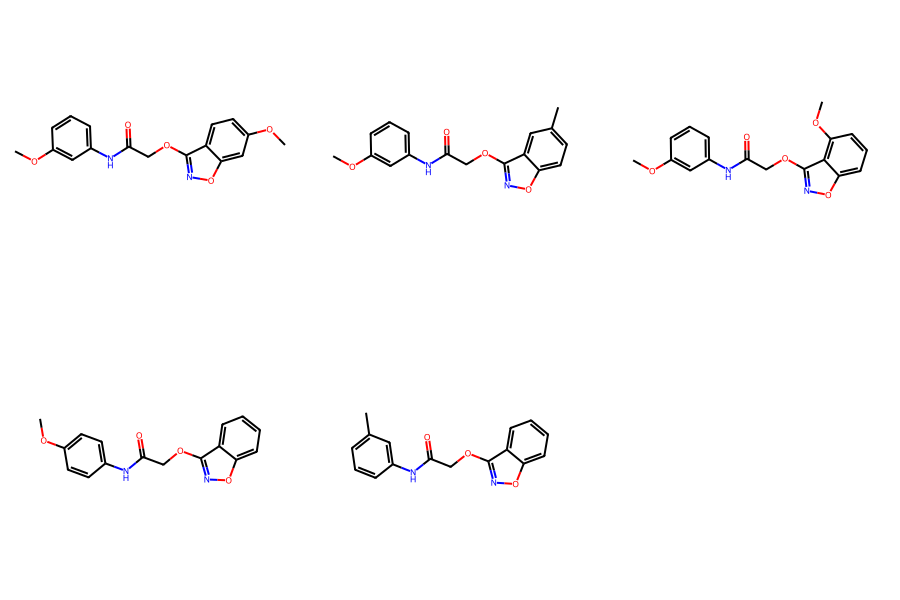

In [407]:
from rdkit.Chem import Draw

shortlist_ids = [43, 42, 44, 4, 14]

mols = [syn.loc[i, "mol"] for i in shortlist_ids]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 300)
)

img


##### Grid with Compound IDs

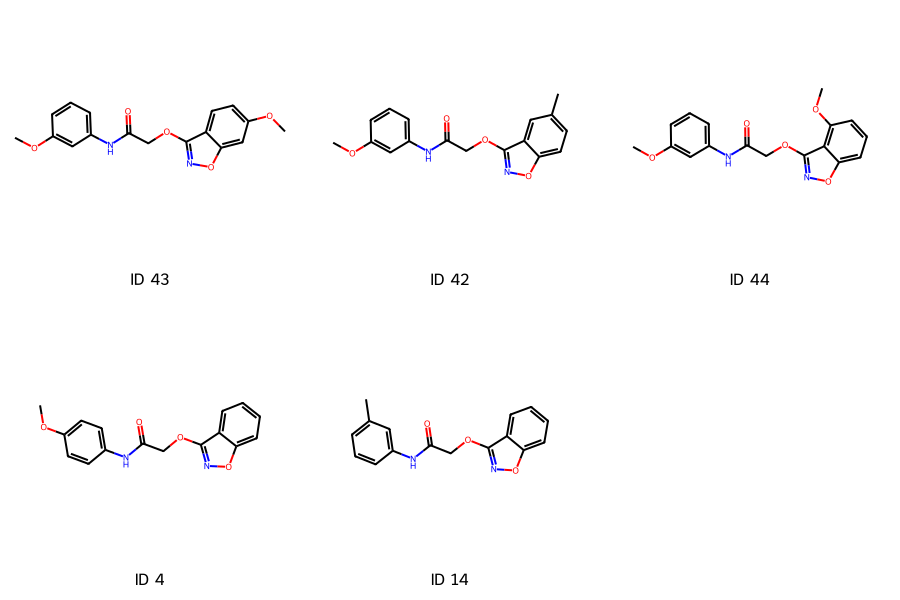

In [409]:
from rdkit.Chem import Draw

shortlist_ids = [43, 42, 44, 4, 14]

mols = [syn.loc[i, "mol"] for i in shortlist_ids]
legends = [f"ID {i}" for i in shortlist_ids]

img = Draw.MolsToGridImage(
    mols,
    legends=legends,
    molsPerRow=3,
    subImgSize=(300, 300)
)

img




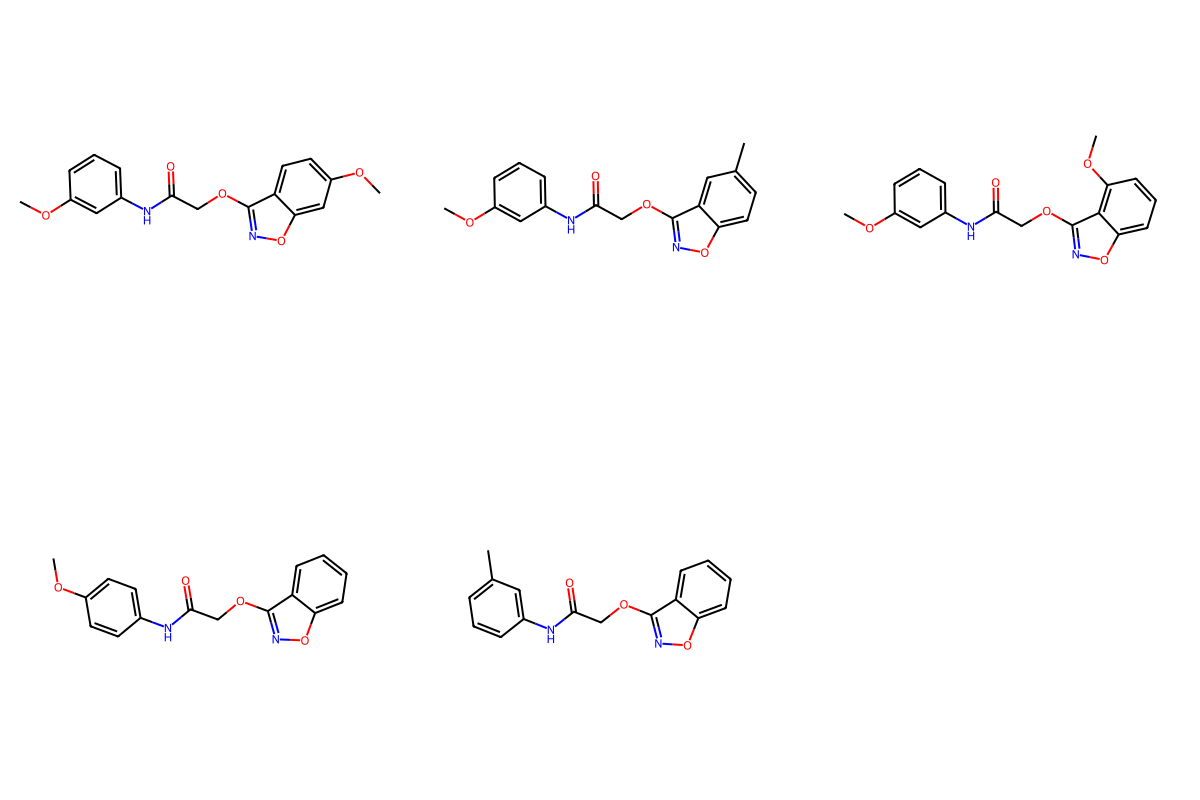

In [412]:
img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(400, 400)
)

img
